# **02. Business and Statistical Analysis**

## Project Overview

This notebook explores the Online Retail II dataset through a comprehensive data analysis pipeline, focusing on revenue concentration, sales patterns, product performance, return behaviour, and customer segmentation.

The main objectives are to identify business patterns, detect anomalies, and extract actionable insights from transactional data.

## Table of Contents

1. [Revenue concentration analysis](#21-revenue-concentration-analysis)
   - [Customer revenue distribution](#211-customer-revenue-distribution)
   - [Product revenue distribution](#212-product-revenue-distribution)
   - [Summary table](#212-summary-table)

2. [Geographic analysis](#22-geographic-analysis)
   - [Sales distribution by country](#221-sales-distribution-by-country)
   - [Revenue distribution by country](#222-revenue-distribution-by-country)
   - [Customer distribution by country](#223-customer-distribution-by-country)

3. [Sales seasonality analysis](#23-sales-seasonality-analysis)
   - [Monthly revenue and sales trends](#231-monthly-revenue-and-sales-trends)
   - [Quarterly revenue and sales trends](#232-quarterly-revenue-and-sales-trends)
   - [Average Order Value](#233-average-order-value-seasonality)

4. [Product performance analysis](#24-product-performance-analysis)
   - [Top selling products](#241-top-selling-products)
   - [Top revenue generating products](#242-top-revenue-generating-products)
   - [volume vs revenue](#243-volume-vs-revenue)

5. [Returns analysis](#25-returns-analysis)
   - [Temporal return trends](#251-return-trends-and-anomaly-detection)
   - [Returns by country](#252-returns-by-country)
   - [Returns by product](#253-returns-by-product)

6. [Customer analysis](#26-customer-analysis)
   - [Customer revenue distribution](#261-customer-revenue-distribution)
   - [RFM Segmentation](#262-rfm-segmentation)

7. [Conclusions](#27-conclusions)

## Project setup

In [ ]:
import sys
sys.path.append('../src')
from functions import *

import numpy as np
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from scipy.stats import spearmanr, linregress


In [2]:
df_sales = pd.read_csv("../data/sales_clean.csv",dtype={"Customer ID": "str"})
df_returns = pd.read_csv("../data/returns_clean.csv",dtype={"Customer ID": "str"})

In [3]:
# create SQLite database
engine = create_engine("sqlite:///../data/retail.db")

# load dataframes
df_sales.to_sql('sales', engine, if_exists='replace', index=False)
df_returns.to_sql('returns', engine, if_exists='replace', index=False)

17915

## 2.1 Revenue concentration analysis

In this first section, we analyze the distribution of gross revenue across customers and products, with the aim of understanding how the contribution to total revenue is distributed among different entities. Since revenue distributions in retail datasets are often highly concentrated, we investigate this concentration using two complementary measures:

1.    Pareto threshold: identifies the fraction of customers (or products) responsible for generating a given percentage of total revenue. In this analysis, we focus on the 80/20 rule, measuring the percentage of entities accounting for 80% of the total revenue.

2.    Gini coefficient: provides a quantitative measure of inequality in the revenue distribution. It ranges from 0 (perfect equality, where all customers or products contribute equally) to 1 (maximum inequality, where a single entity accounts for all revenue).

> Note: It was previously observed that some products and customers have a negative net revenue; this is due to a revenue loss from returns higher than the revenue gain from sales, and is probably a consequence of unregistered sales from previous years. For this reason, in this section we only focus on the gross revenue, ignoring revenue loss due to returns.

### 2.1.1 Customer revenue distribution

In [77]:
q_cust_sal = """
    SELECT SUM(Quantity*Price) AS revenue, "Customer ID"
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
    ORDER BY revenue DESC
    """
df_cust_sal = pd.read_sql(q_cust_sal, engine)
df_cust_sal["revenue_pct"] = df_cust_sal["revenue"]/df_cust_sal["revenue"].sum() *100

pareto_point, pareto_revenue, customers_pct = get_pareto(df_cust_sal)

Text(0.5, 1.0, 'Customers Revenue Distribution (log scale, log bins)')

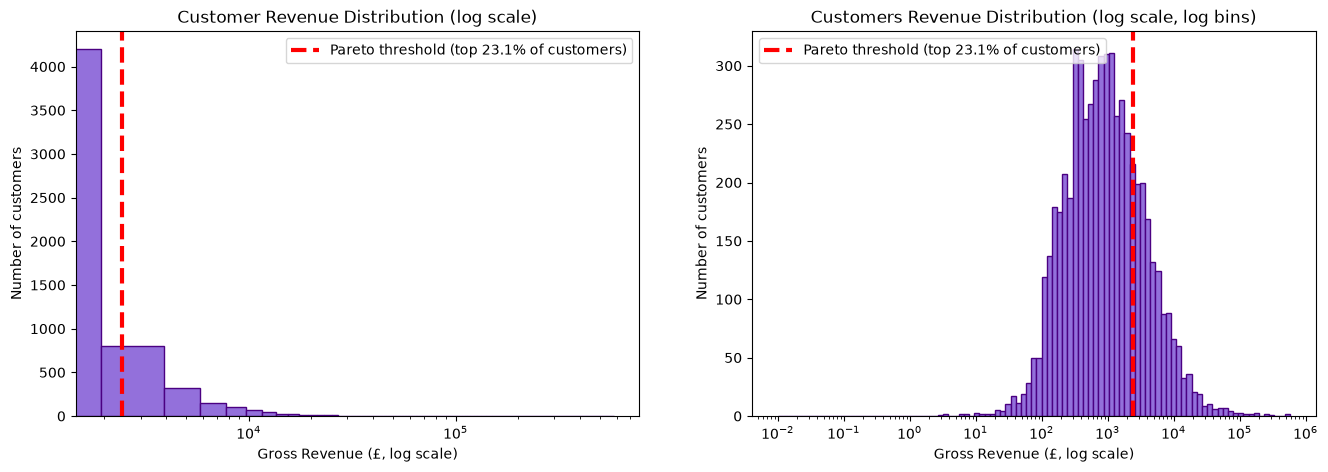

In [78]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

cust_sal_h, bins, _ = ax[0].hist(df_cust_sal["revenue"], bins=300, color="mediumpurple", edgecolor="indigo")
ax[0].set_xscale("log")
ax[0].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {customers_pct:.1f}% of customers)',linewidth=3)
ax[0].legend()
ax[0].set_xlabel("Gross Revenue (£, log scale)")
ax[0].set_ylabel("Number of customers")
ax[0].set_title("Customer Revenue Distribution (log scale)")

bins_log = np.logspace(np.log10(df_cust_sal["revenue"].min()+0.01), 
                   np.log10(df_cust_sal["revenue"].max()), 
                   100)
cust_sal_hlog = ax[1].hist(df_cust_sal["revenue"], bins=bins_log,color="mediumpurple", edgecolor="indigo" )
ax[1].set_xscale("log")
ax[1].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {customers_pct:.1f}% of customers)',linewidth=3)
ax[1].legend()
ax[1].set_xlabel("Gross Revenue (£, log scale)")
ax[1].set_ylabel("Number of customers")
ax[1].set_title("Customers Revenue Distribution (log scale, log bins)")

In [79]:
print(f"Mean: £{df_cust_sal['revenue'].mean():,.0f}")
print(f"Median: £{df_cust_sal['revenue'].median():,.0f}")
print(f"Skewness: {df_cust_sal['revenue'].skew():.2f}")

Mean: £2,916
Median: £856
Skewness: 25.33


The revenue distribution is heavily right-skewed, with a skewness of 25.33. This indicates that the majority of customers generate relatively low revenue, making the median a more representative measure of central tendency than the mean. The long right tail suggests that only a small fraction of customers contributes disproportionately to the total revenue.

This observation is consistent with the Pareto analysis: the long right tail corresponds to the 23.1% of customers responsible for 80% of the total revenue.

This pattern can be further quantified using the Gini coefficient.

In [80]:
gini_customers = gini(df_cust_sal["revenue"].values)
print(f"Gini coefficient (customers): {gini_customers:.3f}")

Gini coefficient (customers): 0.741


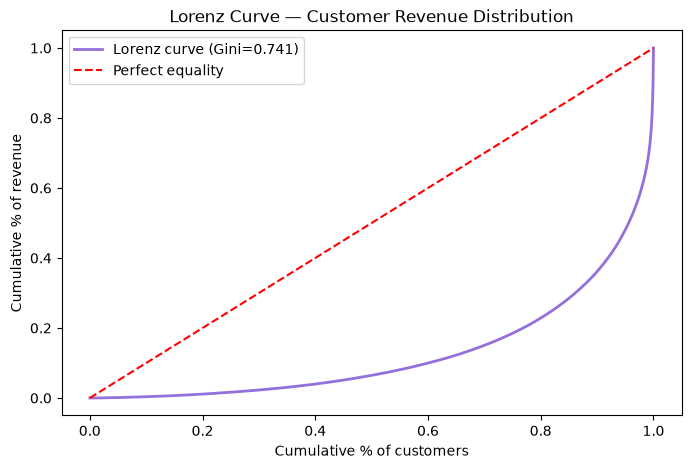

In [81]:
sorted_rev = np.sort(df_cust_sal["revenue"].values)
cumulative_rev = np.cumsum(sorted_rev) / sorted_rev.sum()
cumulative_pop = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

plt.figure(figsize=(8,5))
plt.plot(cumulative_pop, cumulative_rev, label=f'Lorenz curve (Gini={gini_customers:.3f})', c="mediumpurple", linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect equality')
plt.xlabel("Cumulative % of customers")
plt.ylabel("Cumulative % of revenue")
plt.title("Lorenz Curve — Customer Revenue Distribution")
plt.legend()

The Gini coefficient of 0.74 reveals a strong dependence on high-value customers. Combined with the Pareto analysis, this suggests that a relatively small fraction of customers contributes disproportionately to the company's revenue, highlighting the importance of customer retention strategies targeted at these high-value segments.

### 2.1.2 Product revenue distribution

In [82]:
q_prod_sal = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(Price*Quantity) as revenue
    FROM sales
    GROUP BY stock_code
    ORDER BY revenue DESC
    """

df_prod_sal = pd.read_sql(q_prod_sal, engine)
df_prod_sal["revenue_pct"] = df_prod_sal["revenue"]/df_prod_sal["revenue"].sum() *100

pareto_point, pareto_revenue, products_pct = get_pareto(df_prod_sal)

Text(0.5, 1.0, 'Products Revenue Distribution (log scale, log bins)')

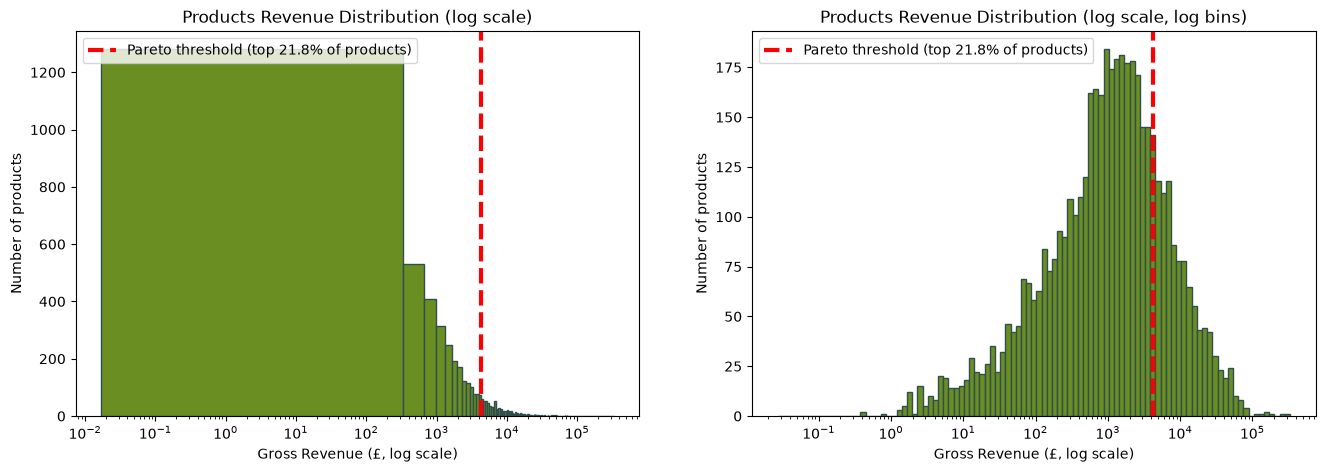

In [83]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

prod_rev_h, bins, _ = ax[0].hist(df_prod_sal["revenue"], bins=1000, color="olivedrab", edgecolor="darkslategrey")
ax[0].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {products_pct:.1f}% of products)', linewidth = 3)
ax[0].legend()
ax[0].set_xscale("log")
ax[0].set_xlabel("Gross Revenue (£, log scale)")
ax[0].set_ylabel("Number of products")
ax[0].set_title("Products Revenue Distribution (log scale)")


bins_log = np.logspace(np.log10(df_prod_sal["revenue"].min()+0.01), 
                   np.log10(df_prod_sal["revenue"].max()), 
                   100)
prod_rev_hlog = ax[1].hist(df_prod_sal["revenue"], bins=bins_log,color="olivedrab", edgecolor="darkslategrey")
ax[1].set_xscale("log")
ax[1].axvline(x=pareto_revenue, color='red', linestyle='--', label=f'Pareto threshold (top {products_pct:.1f}% of products)', linewidth = 3)
ax[1].legend()
ax[1].set_xlabel("Gross Revenue (£, log scale)")
ax[1].set_ylabel("Number of products")
ax[1].set_title("Products Revenue Distribution (log scale, log bins)")

In [84]:
print(f"Mean: £{df_prod_sal['revenue'].mean():,.0f}")
print(f"Median: £{df_prod_sal['revenue'].median():,.0f}")
print(f"Skewness: {df_prod_sal['revenue'].skew():.2f}")

Mean: £4,157
Median: £1,126
Skewness: 11.99


The revenue distribution by products is also right-skewed, with a skewness of 11.99. This indicates that the majority of products have a relatively low price, and the 21.8% of high-cost products contribute to 80% of the total revenue.   

Let us compute the Gini coefficient:

In [85]:
gini_products = gini(df_prod_sal["revenue"].values)
print(f"Gini coefficient (products): {gini_products:.3f}")

Gini coefficient (products): 0.747


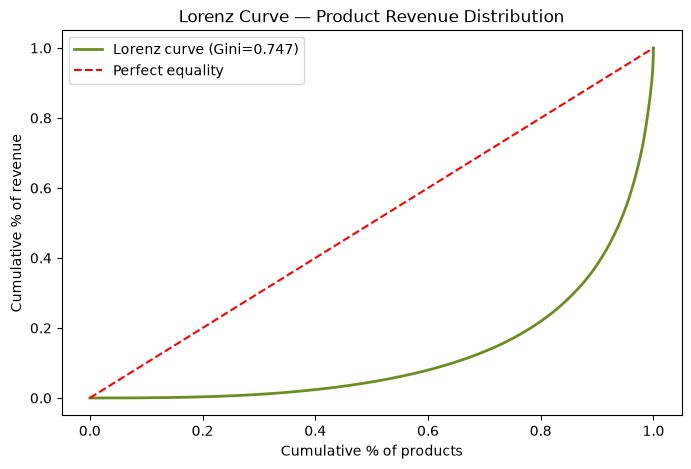

In [86]:
sorted_rev = np.sort(df_prod_sal["revenue"].values)
cumulative_rev = np.cumsum(sorted_rev) / sorted_rev.sum()
cumulative_pop = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

plt.figure(figsize=(8,5))
plt.plot(cumulative_pop, cumulative_rev, label=f'Lorenz curve (Gini={gini_products:.3f})', c="olivedrab", linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect equality')
plt.xlabel("Cumulative % of products")
plt.ylabel("Cumulative % of revenue")
plt.title("Lorenz Curve — Product Revenue Distribution")
plt.legend()

The Gini coefficient of 0.75 reveals a strong dependence on high-value customers. Combined with the Pareto analysis, this suggests that a relatively small fraction of products contributes disproportionately to the company's revenue.

### 2.1.3 Summary table

The following table summarizes the computed Gini coefficient and Pareto threshold for customers and products revenue distribution.

In [87]:
df_distr_res = pd.DataFrame({
    "Entity": ["Customers", "Products"],
    "Gini": [gini_customers, gini_products],
    "Pareto point": [f"{customers_pct:.1f}%", f"{products_pct:.1f}%"]
})
df_distr_res

,Entity,Gini,Pareto point
0,Customers,0.740847,23.1%
1,Products,0.747471,21.8%


## 2.2 Geographic analysis

This section focuses on the geographical analysis of sales, in order to answer the following questions:

1.    Where do most sales come from?

2.    Which country contributes the most to total revenue?     

3.    How are customers distributed across countries?

### 2.2.1 Sales distribution by country

In [33]:
q_country_vol = """
    SELECT SUM(Quantity) as volume, Country
    FROM sales
    GROUP BY Country
    ORDER BY volume DESC
    """

df_country_vol = pd.read_sql(q_country_vol, engine)
df_country_vol["volume_pct"] = df_country_vol["volume"]/df_country_vol["volume"].sum() *100

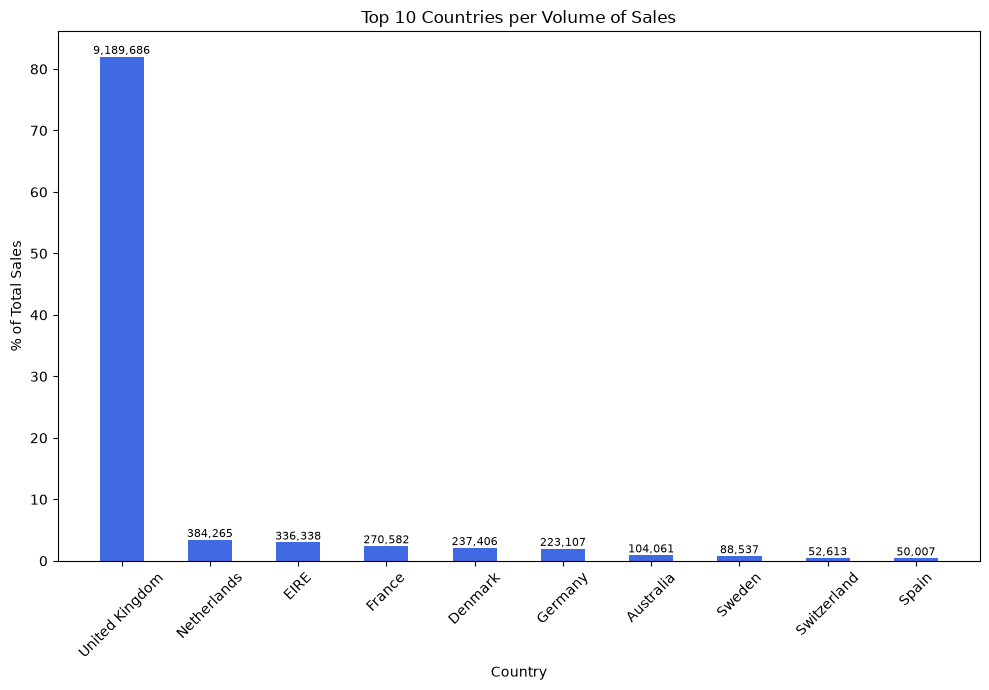

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(df_country_vol["Country"][:10], 
              df_country_vol["volume_pct"][:10], 
              width=0.5, color="royalblue")

for bar, val in zip(bars, df_country_vol["volume"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Sales")
ax.set_title("Top 10 Countries per Volume of Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
uk_vol = df_country_vol[df_country_vol["Country"]=="United Kingdom"]["volume_pct"].item()

print(f"United Kingdom is responsible for {uk_vol:.2f}% of the total volume of sales.")

United Kingdom is responsible for 82.03% of the total volume of sales.


### 2.2.2 Revenue distribution by country

In [63]:
q_country_net_rev = """
    SELECT SUM(Price*Quantity) AS revenue, Country
    FROM (SELECT Country, Price, Quantity FROM sales
        UNION ALL
        SELECT Country, Price, Quantity FROM returns
        )
    GROUP BY Country
    ORDER BY revenue DESC
    """

df_country_net_rev = pd.read_sql(q_country_net_rev, engine)
df_country_net_rev["revenue_pct"]=df_country_net_rev["revenue"]/(df_country_net_rev["revenue"].sum())*100

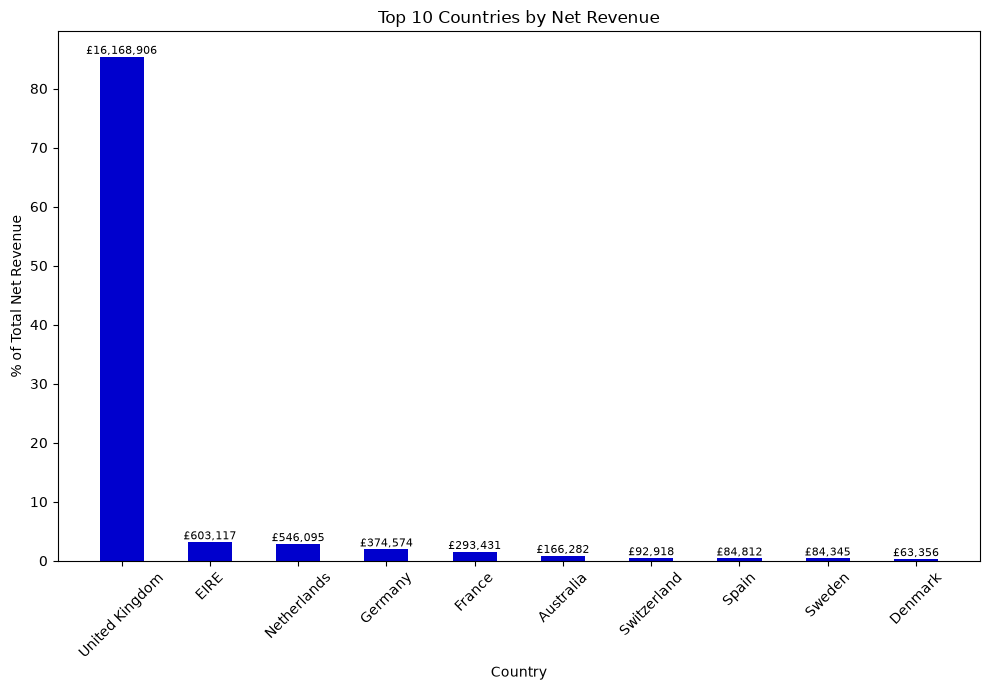

In [64]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(df_country_net_rev["Country"][:10], 
              df_country_net_rev["revenue_pct"][:10], 
              width=0.5, color="mediumblue")

for bar, val in zip(bars, df_country_net_rev["revenue"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'£{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Net Revenue")
ax.set_title("Top 10 Countries by Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
uk_rev = df_country_net_rev[df_country_net_rev["Country"]=="United Kingdom"]["revenue_pct"].item()

print(f"United Kingdom is responsible for {uk_rev:.2f}% of the total net revenue.")

United Kingdom is responsible for 85.43% of the total net revenue.


### 2.2.3 Customers distribution by country

In [66]:
q_cust_country = """
    SELECT COUNT(*) AS customers, Country
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY Country
    ORDER BY customers DESC
    """
df_cust_country = pd.read_sql(q_cust_country, engine)
df_cust_country["customers_pct"] = df_cust_country["customers"]/df_cust_country["customers"].sum() * 100

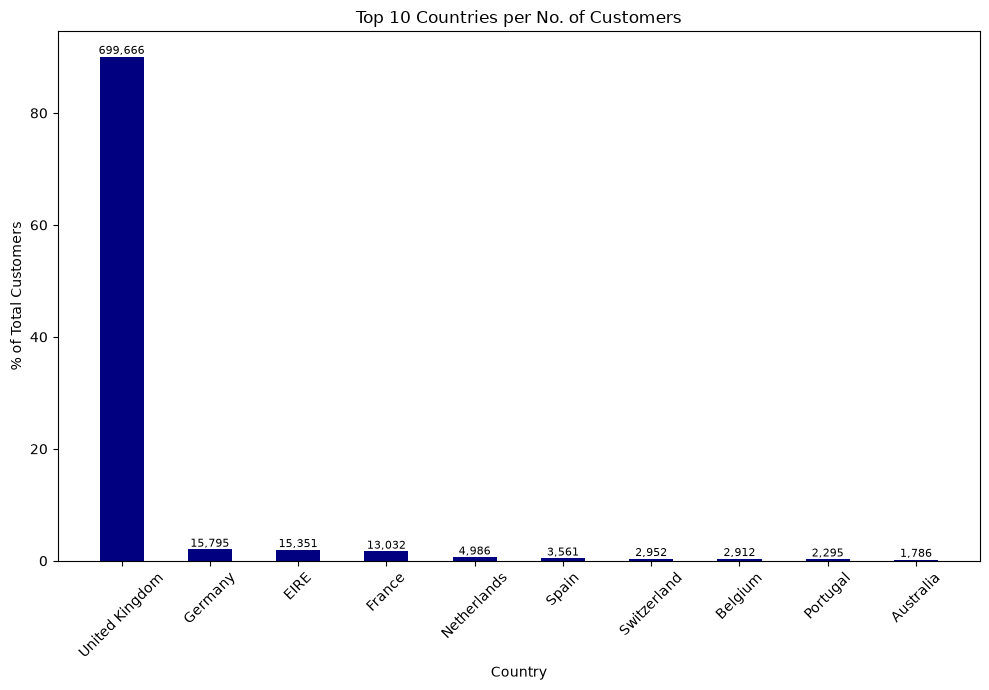

In [41]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(df_cust_country["Country"][:10], 
              df_cust_country["customers_pct"][:10], 
              width=0.5, color="navy")

for bar, val in zip(bars, df_cust_country["customers"][:10]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Country")
ax.set_ylabel("% of Total Customers")
ax.set_title("Top 10 Countries per No. of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
uk_cust = df_cust_country[df_cust_country["Country"]=="United Kingdom"]["customers_pct"].item()
print(f"{uk_cust:.2f}% of customers come from the United Kingdom.")

90.09% of customers come from the United Kingdom.


The geographical analysis tells a clear story: most of the contribution to the company's sales and revenue comes from the UK, which constitutes 90.09% of the customerbase.    
UK customers account for 85.34% of the total revenue and 82.03% of total sales.

## 2.3 Sales seasonality analysis

In this section, we investigate the temporal dynamics of the business by analyzing the seasonality of revenue and sales volume. The objective is to identify recurring patterns in demand and understand whether specific periods of the year consistently generate higher sales activity.    
In regards to revenue, we will observe the temporal behaviour of both the sales revenue and net revenue (accountig for returns).


Both monthly and quarterly aggregations are considered to capture different levels of seasonality and evaluate the contribution of each period to the overall yearly performance.

### 2.3.1 Monthly revenue and sales trends

In [88]:
q_net_revenue = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    GROUP BY year_month
    ORDER BY year_month
    """

q_sales = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Price*Quantity) AS revenue
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """

q_sal_vol = """
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month, SUM(Quantity) AS volume
    FROM sales
    GROUP BY year_month
    ORDER BY year_month
    """

df_net_rev = pd.read_sql(q_net_revenue,engine) # Net revenue
df_sal_rev = pd.read_sql(q_sales,engine)   # Sales revenue
df_sal_vol = pd.read_sql(q_sal_vol,engine)   # Sales volume

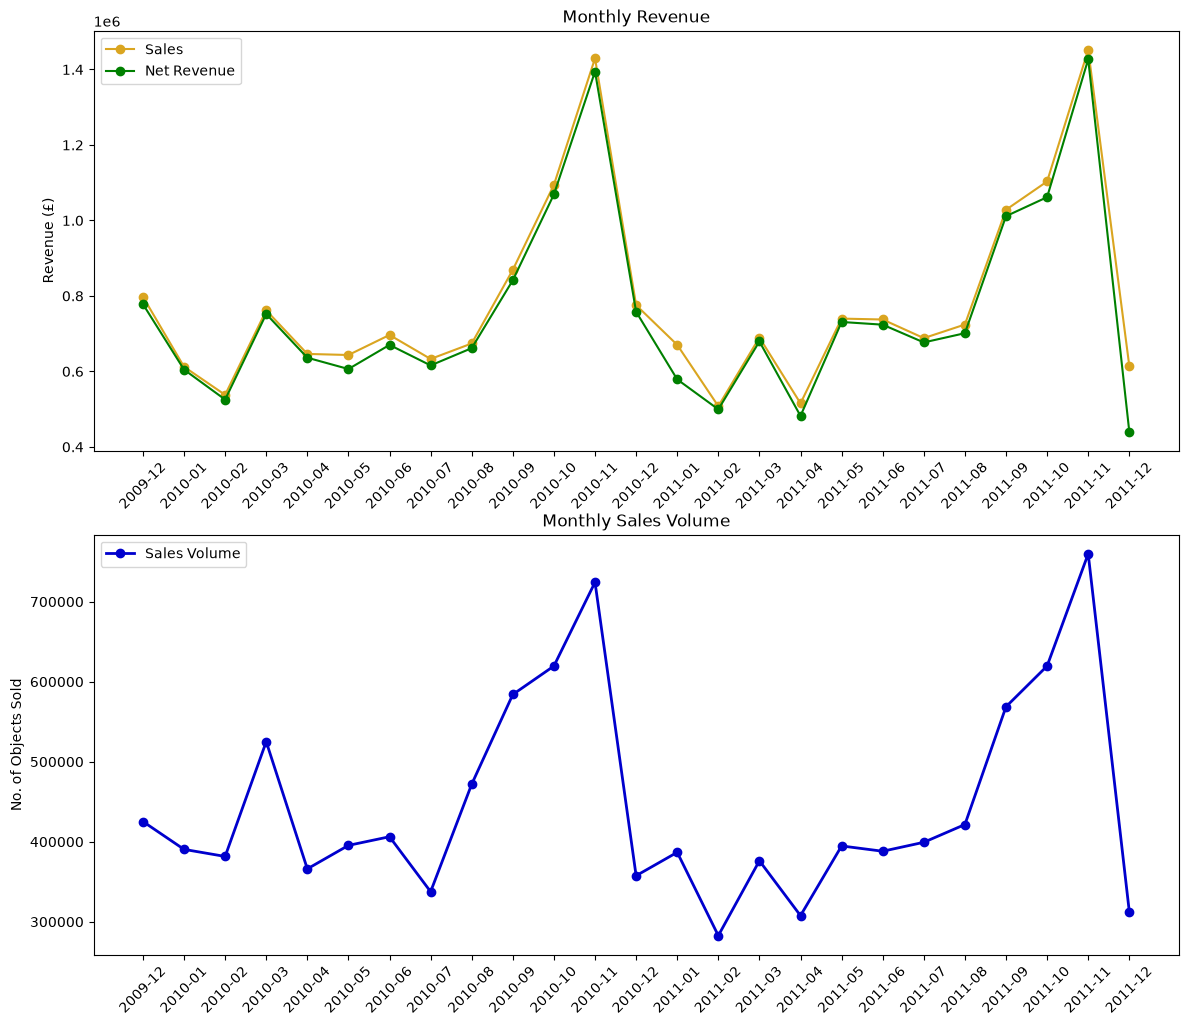

In [89]:
# Plot results
fig, ax =plt.subplots(2,1,figsize=(14,12))

ax[0].plot(df_sal_rev["year_month"], df_sal_rev["revenue"],c="goldenrod", label="Sales", marker='o')
ax[0].plot(df_net_rev["year_month"], df_net_rev["revenue"],c="green", label="Net Revenue", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Monthly Revenue")
ax[0].set_ylabel("Revenue (£)")
ax[0].legend()

ax[1].plot(df_sal_vol["year_month"], df_sal_vol["volume"],c="mediumblue",linewidth=2, label="Sales Volume", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Monthly Sales Volume")
ax[1].set_ylabel("No. of Objects Sold")
ax[1].legend()

### 2.3.2 Quarterly revenue and sales trends

For the quarterly trends, the year 2009 is not considered since the only available data for that specific year refers to December.

In [90]:
q_net_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM (SELECT InvoiceDate, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Price, Quantity FROM returns
        )
    WHERE year!='2009'
    GROUP BY year, quarter
    """

q_sal_rev_quart = """
    SELECT SUM(Price*Quantity) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """

q_vol_quart = """
    SELECT SUM(Quantity) AS volume, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM sales
    WHERE year!='2009'
    GROUP BY year, quarter
    """


df_net_rev_quart = pd.read_sql(q_net_rev_quart,engine)
df_sal_rev_quart = pd.read_sql(q_sal_rev_quart,engine)
df_sal_quart = pd.read_sql(q_vol_quart,engine)

df_net_rev_quart["year_quarter"] = df_net_rev_quart["year"] + "-" + df_net_rev_quart["quarter"]
df_sal_rev_quart["year_quarter"] = df_sal_rev_quart["year"] + "-" + df_sal_rev_quart["quarter"]
df_sal_quart["year_quarter"] = df_sal_quart["year"] + "-" + df_sal_quart["quarter"]

Text(0, 0.5, 'No. of Objects Sold')

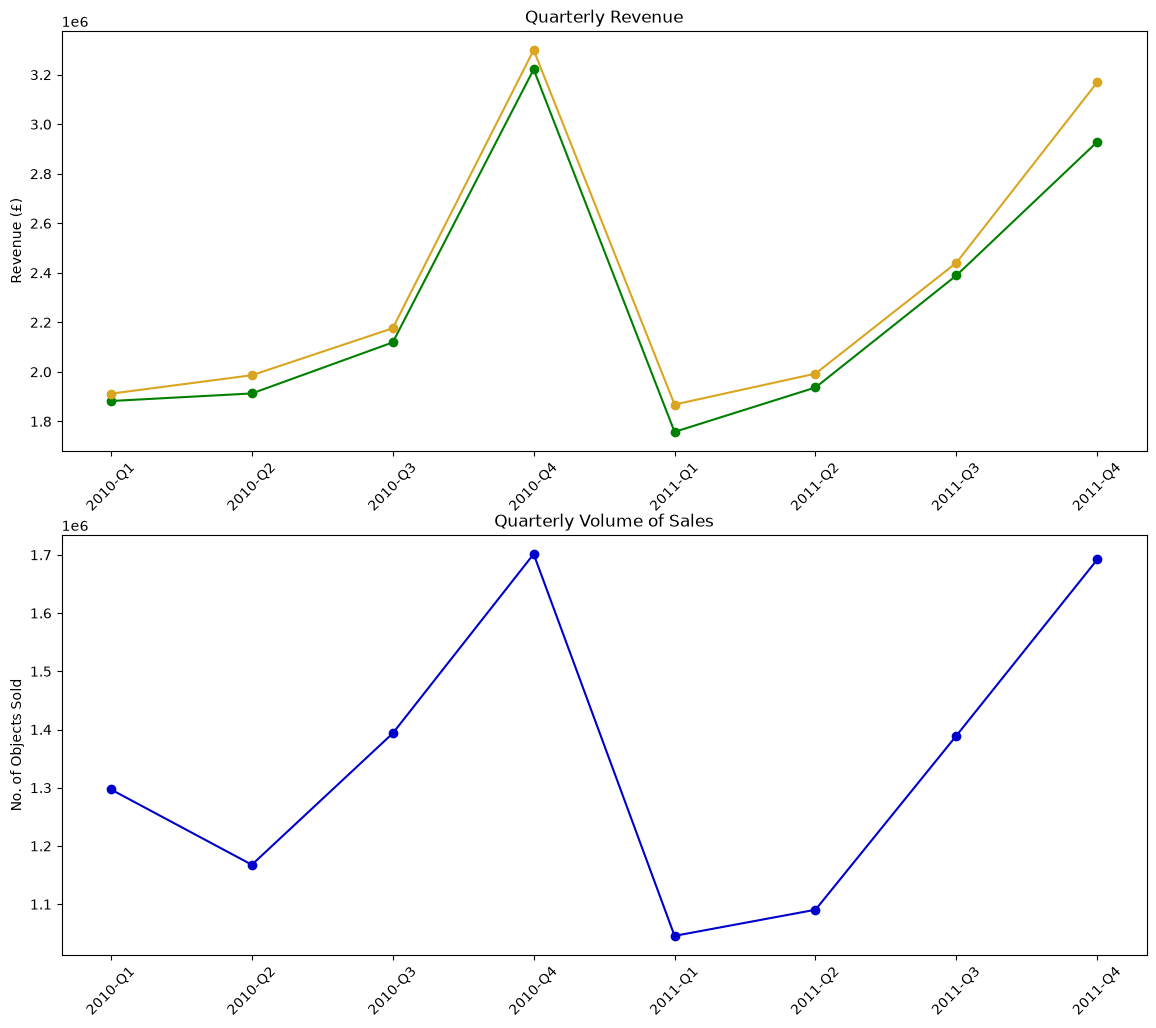

In [91]:
fig, ax = plt.subplots(2,1,figsize=(14,12))

ax[0].plot(df_net_rev_quart["year_quarter"], df_net_rev_quart["revenue"],c="green", marker='o', label="Net Revenue")
ax[0].plot(df_sal_rev_quart["year_quarter"], df_sal_rev_quart["revenue"],c="goldenrod", marker='o', label="Sales Revenue")
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Quarterly Revenue")
ax[0].set_ylabel("Revenue (£)")

ax[1].plot(df_sal_quart["year_quarter"], df_sal_quart["volume"],c="mediumblue", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Quarterly Volume of Sales")
ax[1].set_ylabel("No. of Objects Sold")

From these trends, we can draw two main observations:

1.    Sales volume and revenue exhibit similar temporal patterns, suggesting that periods with higher purchasing activity are generally associated with higher revenue generation.

2.   A consistent increase in both sales volume and revenue can be observed around November and December of each year, with Q4 representing the strongest performing period. This pattern is consistent with the so-called "holiday effect", where consumer spending typically increases during the Christmas shopping period.

### 2.3.3 Average Order Value

The previous results suggest that fluctuations in purchasing activity are the main driver of revenue variations.   
It might be now interesting to investigate whether the higher revenue observed in high-sales period is the result of a higher number of orders placed or a higher value of each single order. 
To do so, we can analyze the trends in number of transactions and in average order value, defined as: $$AOV=\dfrac{\text{Net revenue}}{\text{Number of Transactions}}$$

In [71]:
q_aov_quart = """
    SELECT COUNT(DISTINCT Invoice) AS transactions, SUM(Quantity*Price) AS revenue, strftime('%Y', InvoiceDate) AS year,
    CASE
        WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
        WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
        WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
        WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
    END AS quarter
    FROM (SELECT InvoiceDate, Invoice, Price, Quantity FROM sales
        UNION ALL
        SELECT InvoiceDate, Invoice, Price, Quantity FROM returns
        )
    WHERE year!='2009'
    GROUP BY year, quarter
    """
df_aov_quart = pd.read_sql(q_aov_quart, engine)
df_aov_quart["year_quarter"] = df_aov_quart["year"] + "-" + df_aov_quart["quarter"]


Text(0, 0.5, 'Average Order Value (£)')

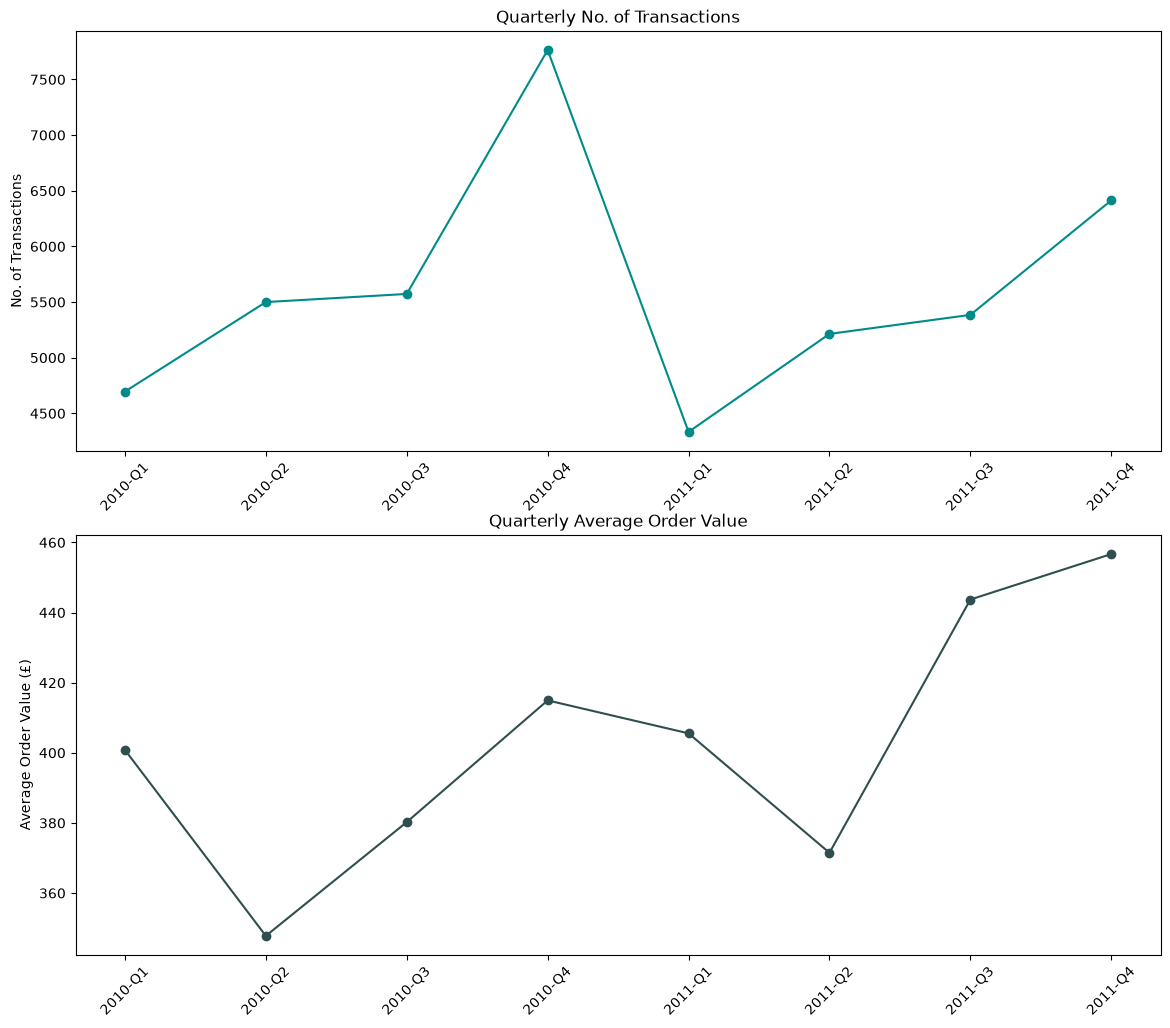

In [73]:
fig, ax = plt.subplots(2,1,figsize=(14,12))

ax[0].plot(df_aov_quart["year_quarter"], df_aov_quart["transactions"],c="darkcyan", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Quarterly No. of Transactions")
ax[0].set_ylabel("No. of Transactions")

ax[1].plot(df_aov_quart["year_quarter"], df_aov_quart["revenue"]/df_aov_quart["transactions"],c="darkslategray", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Quarterly Average Order Value")
ax[1].set_ylabel("Average Order Value (£)")

The quarterly trends of the number of transactions and the Average Order Value (AOV) provide additional insight into the seasonal increase in revenue observed during Q4. In both years, the number of transactions reaches its highest level during the last quarter, indicating that more purchase orders are placed during the holiday season. At the same time, the AOV also increases, suggesting that customers tend to spend more on each order. Therefore, the Q4 revenue peak appears to be driven by the combined effect of an increased purchasing activity and a higher average value per transaction.

### 2.3.4 Q4 Seasonal uplift

Finally, we can quantify the increase in revenue in Q4 of each year by computing the seasonal uplift, i.e.:
$$\text{Q4 uplift}=\dfrac{\text{Revenue}_\text{Q4}-\text{Revenue}_\text{Q1-2-3}}{\text{Revenue}_\text{Q1-2-3}}$$
Where we consider as $\text{Revenue}_\text{Q1-2-3}$ the average net revenue over the first three quarters.

In [96]:
rev_q123_2010 = df_net_rev_quart[(df_net_rev_quart["year"]=="2010") & (df_net_rev_quart["quarter"]!="Q4")]["revenue"].mean()
rev_q123_2011 = df_net_rev_quart[(df_net_rev_quart["year"]=="2011") & (df_net_rev_quart["quarter"]!="Q4")]["revenue"].mean()
rev_q4_2010 = df_net_rev_quart[(df_net_rev_quart["year"]=="2010") & (df_net_rev_quart["quarter"]=="Q4")]["revenue"].item()
rev_q4_2011 = df_net_rev_quart[(df_net_rev_quart["year"]=="2011") & (df_net_rev_quart["quarter"]=="Q4")]["revenue"].item()

uplift_q4_2010 = (rev_q4_2010-rev_q123_2010)/(rev_q123_2010)
uplift_q4_2011 = (rev_q4_2011-rev_q123_2011)/(rev_q123_2011)


df_q4_uplift = pd.DataFrame({
    "Year":["2010","2011"],
    "Q4 net revenue": [rev_q4_2010, rev_q4_2011],
    "Q1-2-3 avg. net revenue": [rev_q123_2010, rev_q123_2011],
    "Q4 uplift": [f"{uplift_q4_2010*100:.2f}%", f"{uplift_q4_2011*100:.2f}%"]})

df_q4_uplift

,Year,Q4 net revenue,Q1-2-3 avg. net revenue,Q4 uplift
0,2010,3221677.212,1971383.704,63.42%
1,2011,2929225.320,2028000.781,44.44%


The uplift in revenue is significant for both years, although it visibly decreases from 2010 to 2011 from 63.42% to 44.44%.    
This is however not only due to a lower net revenue in Q4 of 2011 compared with 2010, but also to a higher average net revenue of the other quarters of 2011.

## 2.4 Product performance analysis

This section focuses on product performance by analyzing both sales volume and net revenue. Although products with higher sales volumes are generally expected to generate higher revenue, differences in unit price may lead to substantially different rankings.    
Comparing products from these two perspectives allows us to identify the relationship between popularity and economic impact, highlighting whether the best-selling products are also the main revenue generators.

### 2.4.1 Top selling products

In [103]:
q_prod = """
    SELECT UPPER(StockCode) as stock_code, Description, SUM(CASE WHEN Quantity > 0 THEN Quantity ELSE 0 END) as volume, SUM(Price*Quantity) as revenue, Price
    FROM (SELECT StockCode, Description, Price, Quantity FROM sales
        UNION ALL
        SELECT StockCode, Description, Price, Quantity FROM returns
        )
    GROUP BY stock_code
    ORDER BY volume DESC
    """
df_prod = pd.read_sql(q_prod, engine)
df_prod["volume_pct"] = df_prod["volume"]/df_prod["volume"].sum() *100
df_prod["revenue_pct"] = df_prod["revenue"]/df_prod["revenue"].sum() *100


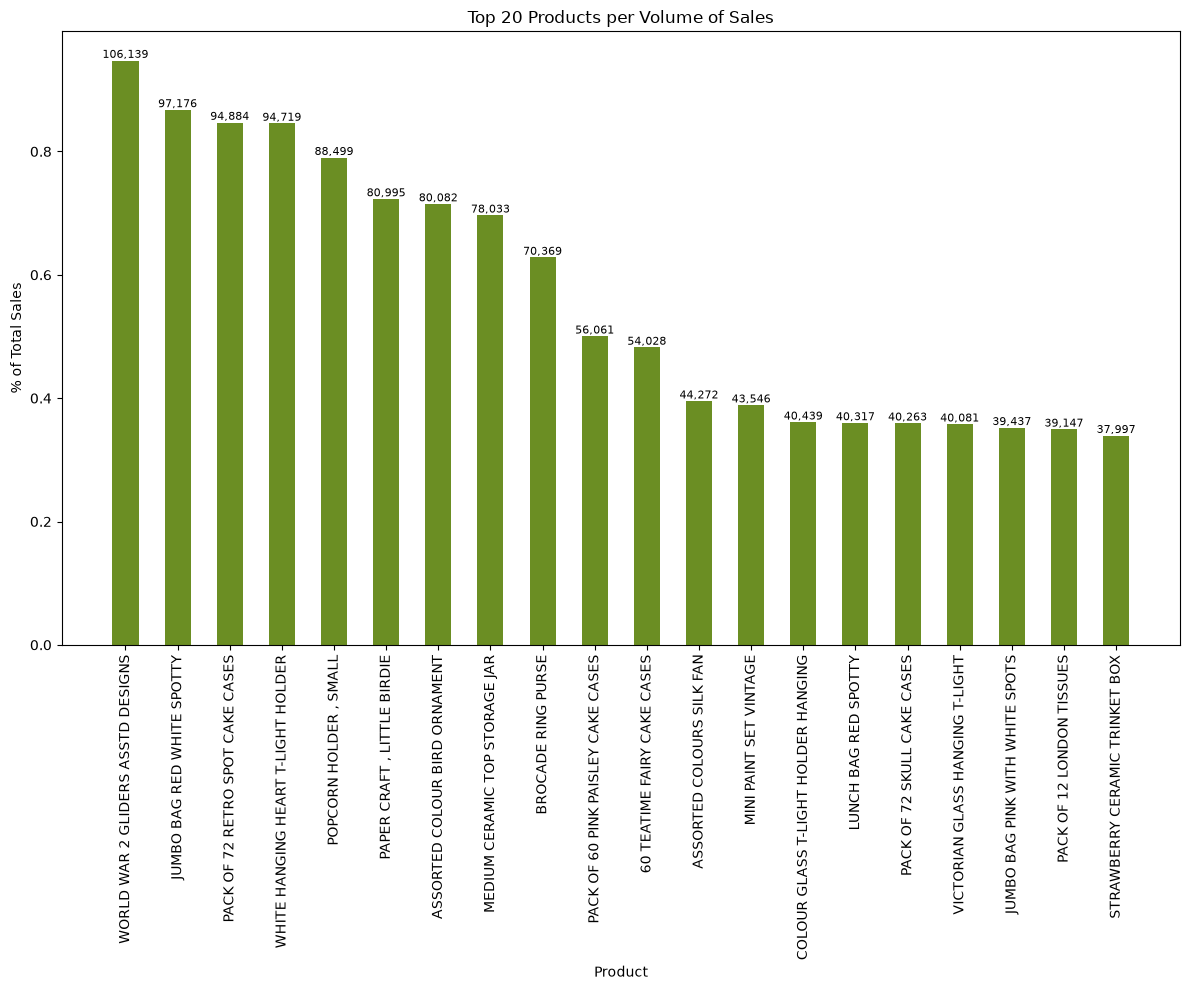

In [104]:
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(df_prod["Description"][:20], 
              df_prod["volume_pct"][:20], 
              width=0.5, color="olivedrab")

for bar, val in zip(bars, df_prod["volume"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Product")
ax.set_ylabel("% of Total Sales")
ax.set_title("Top 20 Products per Volume of Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.4.2 Top revenue generating products

In [85]:
df_prod.sort_values(by=["revenue"], ascending=False, inplace=True)

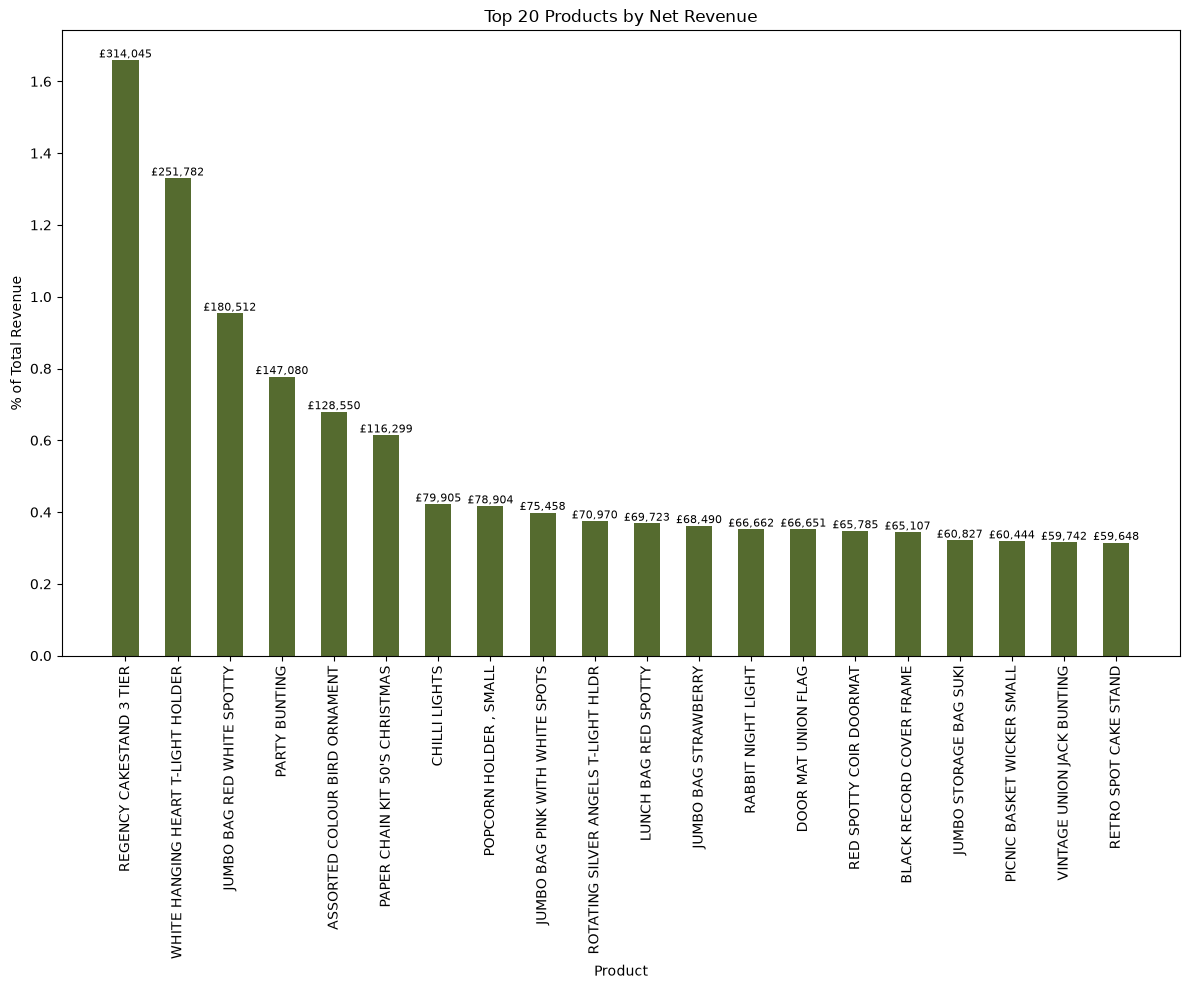

In [86]:
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(df_prod["Description"][:20], 
              df_prod["revenue_pct"][:20], 
              width=0.5, color="darkolivegreen")

for bar, val in zip(bars, df_prod["revenue"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'£{val:,.0f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Product")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 20 Products by Net Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.4.3 Volume VS Revenue

While several products appear in both the top-20 revenue and volume rankings, others are exclusive to one of them, suggesting that popularity and revenue generation are not perfectly aligned.    
We now investigate on the correlation between best-selling products and best revenue generators by employing the Spearman correlation coefficient, that measures monotonic relationship between two non normally distributed variables.    
Although we expect them to be highly corretaled since revenue is proportional to volume of sales, this analysis can help us identify premium products (high-revenue but low-volume) and economic products (high-volume but low-revenue). 

In [105]:
r = spearmanr(df_prod["volume"], df_prod["revenue"])
print(f"Spearman coefficient: {r.statistic:.3f}, p-value: {r.pvalue}")

Spearman coefficient: 0.842, p-value: 0.0


In [119]:
# theshold based on quantiles
vol_threshold = df_prod["volume"].quantile(0.75)
rev_threshold = df_prod["revenue"].quantile(0.75)

# high volume, low revenue
outliers_low = df_prod[(df_prod["volume"] > vol_threshold) & 
                             (df_prod["revenue"] < rev_threshold)]

# high revenue, low volume
outliers_high = df_prod[(df_prod["revenue"] > rev_threshold) & 
                              (df_prod["volume"] < vol_threshold)]

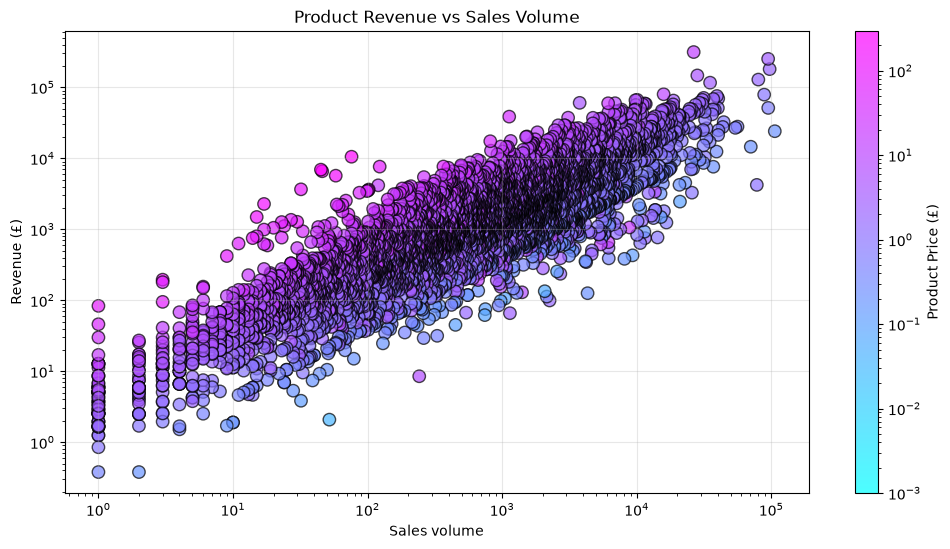

In [118]:
fig,ax = plt.subplots(figsize=(12,6))
scatter = ax.scatter(df_prod["volume"],df_prod["revenue"], c=df_prod["Price"],cmap="cool",alpha=0.7,norm=LogNorm(),edgecolor="black",s=80)
plt.colorbar(scatter, ax=ax, label="Product Price (£)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sales volume")
ax.set_ylabel("Revenue (£)")
ax.set_title("Product Revenue vs Sales Volume")
ax.grid(alpha=0.3)

The Spearman correlation coefficient between sales volume and net revenue across products is 0.84, indicating a strong monotonic relationship between high volume of sales and high revenue. While the magnitude of the coefficient is high, however, its value indicates that exceptions are still present, and we can delve deeper into the analysis by exploring these exceptions.       

This can be done by performing a simple **linear regression in logarithmic scale** which allows us to find the line that better approximate the relationship between sales and revenue; products that represent an exception to the observed correlation can then be easily identified as products with the highest residue, i.e. deviating the most from the predicted line.    
 
Products with non-positive net revenue or sales volume were excluded from the regression analysis, as logarithmic transformation is undefined for non-positive values. These products mainly correspond to items with net returns exceeding recorded sales within the available observation period.

In [123]:
df_fit = df_prod[
    (df_prod["revenue"] > 0) &
    (df_prod["volume"] > 0)
].copy()

In [ ]:
# regression
x = np.log10(df_fit["volume"])
y = np.log10(df_fit["revenue"])

res = linregress(x, y)

slope = res.slope
intercept = res.intercept
pred = slope*x + intercept
r2 = res.rvalue**2


residual = y - pred
df_fit["residual"]=residual

In [167]:
premium_prod = df_fit.nlargest(5, "residual")[["stock_code", "Description","volume","revenue"]]
economic_prod = df_fit.nsmallest(5, "residual")[["stock_code", "Description","volume","revenue"]]
premium_idx = df_fit.nlargest(5, "residual").index
economic_idx = df_fit.nsmallest(5, "residual").index

In the following scatter plot, the top 5 high revenue outliers (high-revenue and low-sales), referred to as "Premium products", and high sales outliers (high sales and low revenue) rferred to as "Economic best sellers" are highlighted. Descriptions of the products is shown in the below tables.

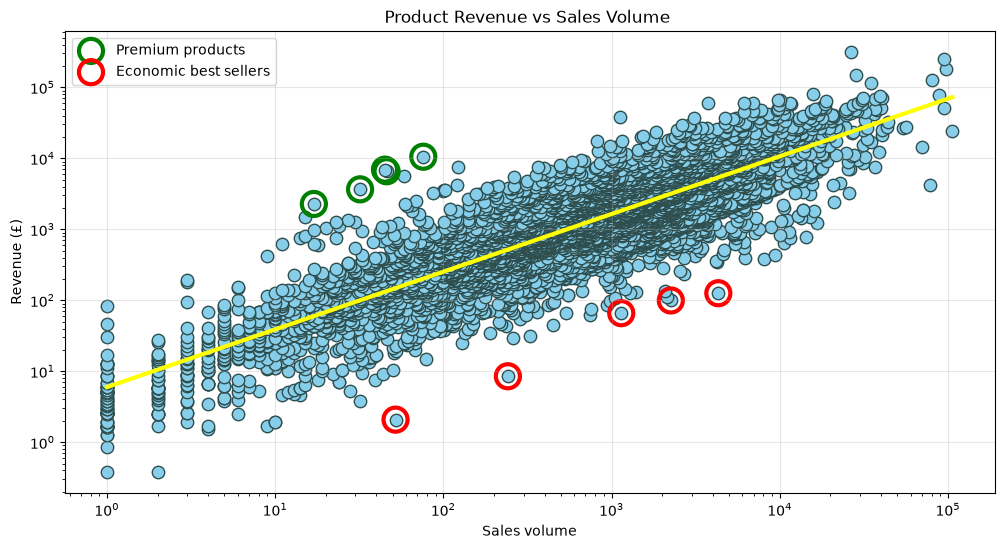

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

scatter = ax.scatter(df_fit["volume"],df_fit["revenue"],color="skyblue",edgecolor="darkslategrey",s=80)
ax.plot(10**x, 10**pred, linewidth=3, color="yellow")

ax.scatter( premium_prod["volume"],premium_prod["revenue"],facecolors="none",edgecolors="green",s=300,linewidths=3,label="Premium products")

ax.scatter(economic_prod["volume"],economic_prod["revenue"],facecolors="none",edgecolors="red",s=300,linewidths=3,label="Economic best sellers")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Sales volume")
ax.set_ylabel("Revenue (£)")
ax.set_title("Product Revenue vs Sales Volume ")
ax.grid(alpha=0.3)
ax.legend()

In [173]:
premium_prod

,stock_code,Description,volume,revenue
4010,22656,VINTAGE BLUE KITCHEN CABINET,45,6921.5
3792,22655,VINTAGE RED KITCHEN CABINET,76,10524.5
4004,22827,GIANT SEVENTEEN DRAWER SIDEBOARD,46,6570.0
4330,22828,REGENCY MIRROR WITH SHUTTERS,17,2275.0
4133,22823,CHEST NATURAL WOOD 20 DRAWERS,32,3655.0


In [174]:
economic_prod

,stock_code,Description,volume,revenue
3951,17061,ASSORTED SHAPED STENCIL FOR HENNA,52,2.08
3142,79323B,BLACK CHERRY LIGHTS,242,8.50
637,16053,POPART COL BALLPOINT PEN ASST,4313,125.73
1146,10123G,ARMY CAMO WRAPPING TAPE,2251,99.32
1816,84493,BLUE/PINK NEST STRIPE BOX,1142,65.76


## 2.5 Returns analysis

This section focuses on the analysis of return rates, with the aim of understanding temporal trends in returns as well as investigate possible causes for returns

### 2.5.1 Temporal return trends

For the temporal analysis of returns we will monitor both the return and the returns rate i.e. the percentage of returns over total sales.    

While they might be similar in trend, they retain different informations and, if coupled, help us in getting the full picture. Although a higher absolute number of returns could indicate issues with a specific product or with the company in a certain period, it might as well be naturally caused by the higher amount of sales: identifying which is the case becomes much simpler if we monitor the return rate. Vice versa, return rate should always be interpreted together with return volume, since high rates can arise from low sales volumes.     

In [78]:
q_ret_month = """
    SELECT s.year_month, s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT strftime('%Y-%m', InvoiceDate) as year_month, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY year_month
    ) s
    LEFT JOIN (
        SELECT strftime('%Y-%m', InvoiceDate) as year_month, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY year_month
    ) r ON s.year_month = r.year_month

    ORDER BY s.year_month
    """


q_ret_quart = """
    SELECT s.year, s.quarter, s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT SUM(Quantity) AS sales_volume, strftime('%Y', InvoiceDate) as year,
        CASE
            WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
        END AS quarter
        FROM sales 
        WHERE year!='2009'
        GROUP BY year, quarter
    ) s
    LEFT JOIN (
        SELECT SUM(ABS(Quantity)) AS return_volume, strftime('%Y', InvoiceDate) as year,
        CASE
            WHEN strftime('%m', InvoiceDate) IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m', InvoiceDate) IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m', InvoiceDate) IN ('07','08','09') THEN 'Q3'
            WHEN strftime('%m', InvoiceDate) IN ('10','11','12') THEN 'Q4'
        END AS quarter
        FROM returns
        WHERE year!='2009'
        GROUP BY year, quarter
    ) r ON s.year = r.year AND s.quarter = r.quarter
    ORDER BY s.year, s.quarter
    """

df_ret_month = pd.read_sql(q_ret_month,engine)
df_ret_quart = pd.read_sql(q_ret_quart,engine)
df_ret_quart["year_quarter"] = df_ret_quart["year"] + "-" + df_ret_quart["quarter"]   

Text(0, 0.5, 'Return Rate (%)')

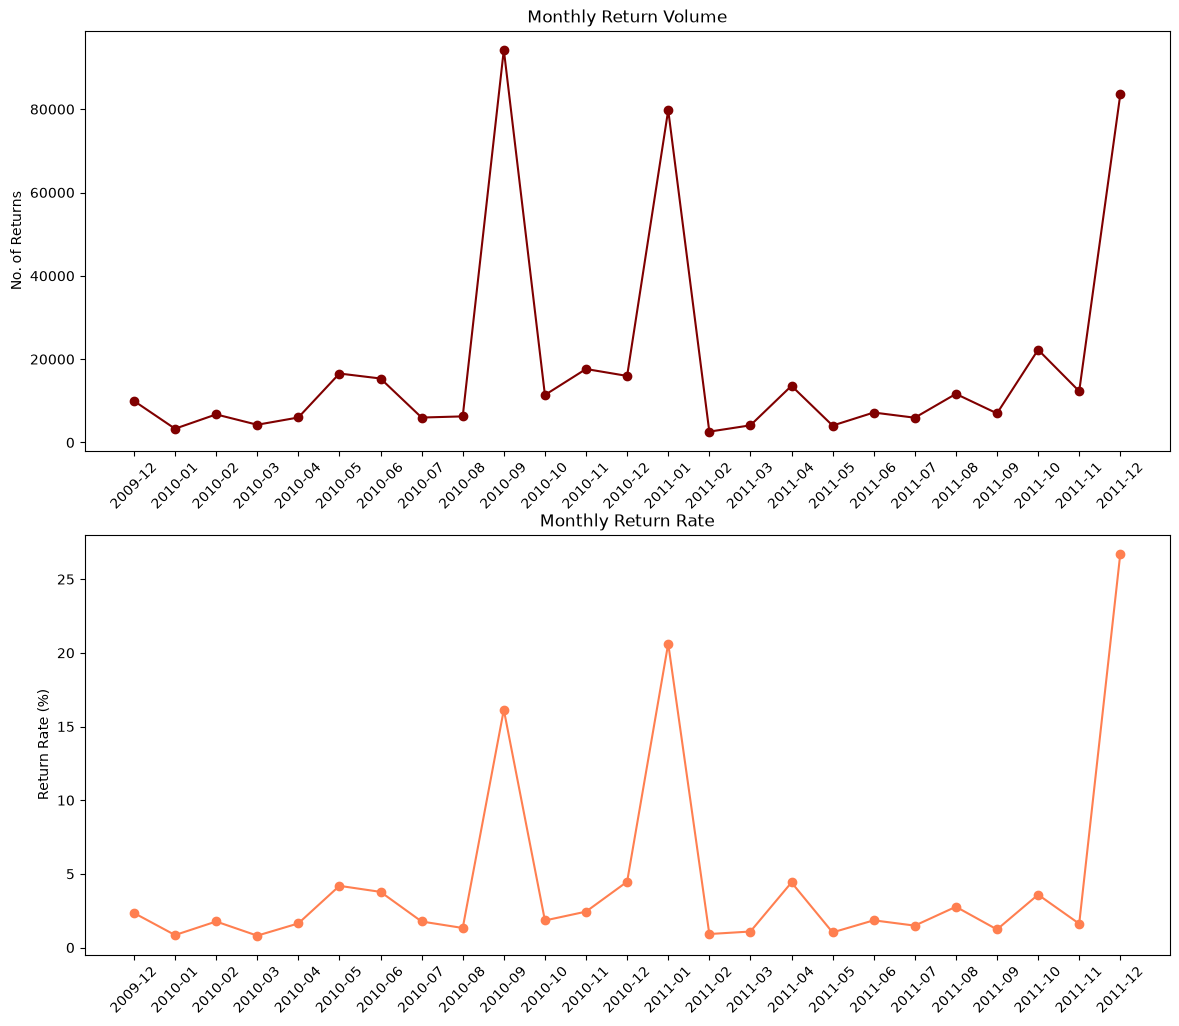

In [79]:
fig, ax = plt.subplots(2,1,figsize=(14,12))
ax[0].plot(df_ret_month["year_month"], df_ret_month["return_volume"],c="maroon", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Monthly Return Volume")
ax[0].set_ylabel("No. of Returns")

ax[1].plot(df_ret_month["year_month"], df_ret_month["return_rate"],c="coral", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Monthly Return Rate")
ax[1].set_ylabel("Return Rate (%)")


Text(0, 0.5, 'Return Rate (%)')

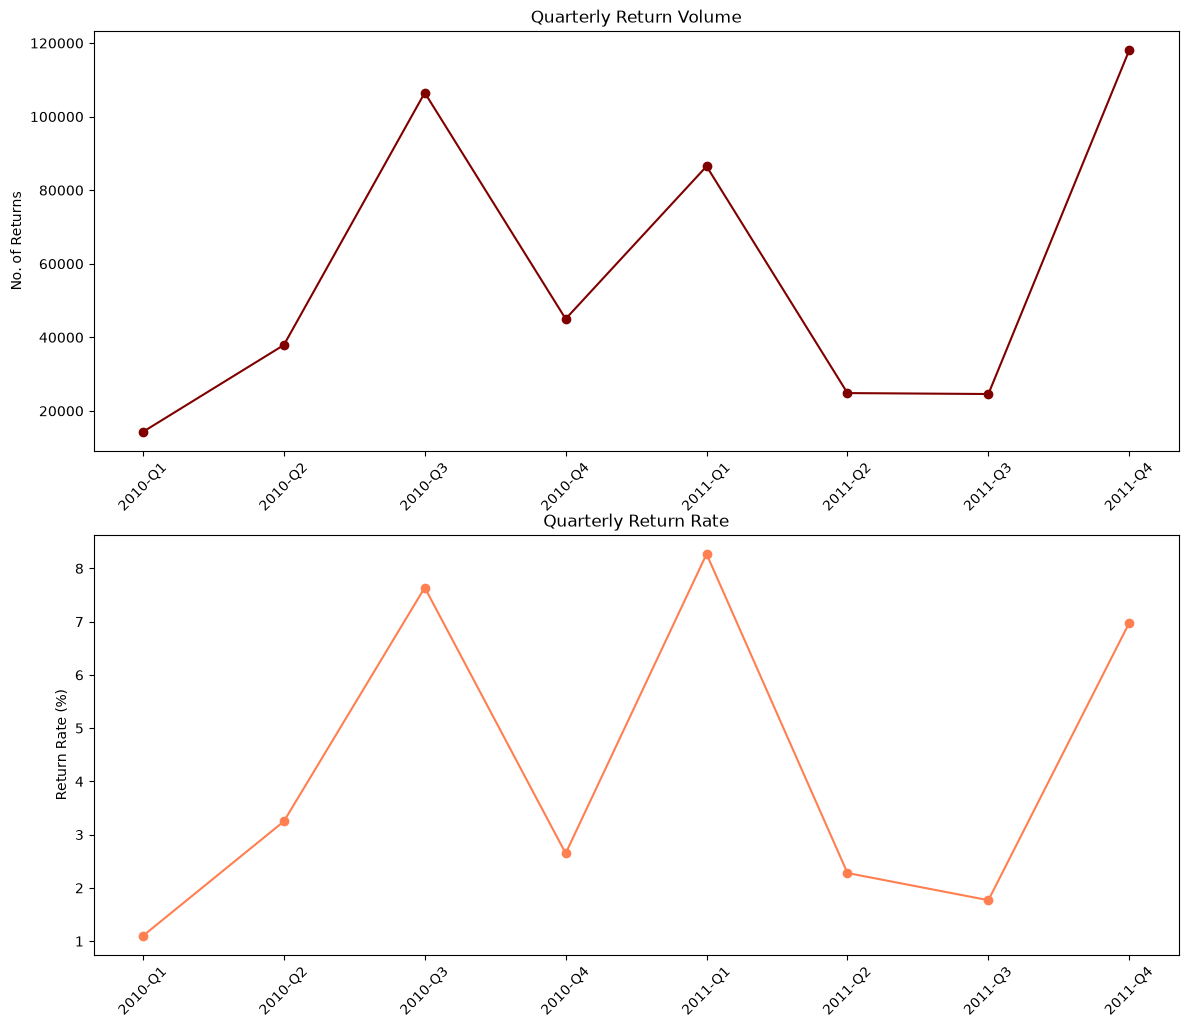

In [80]:
fig, ax = plt.subplots(2,1,figsize=(14,12))
ax[0].plot(df_ret_quart["year_quarter"], df_ret_quart["return_volume"],c="maroon", marker='o')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title("Quarterly Return Volume")
ax[0].set_ylabel("No. of Returns")

ax[1].plot(df_ret_quart["year_quarter"], df_ret_quart["return_rate"],c="coral", marker='o')
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title("Quarterly Return Rate")
ax[1].set_ylabel("Return Rate (%)")

Both monthly and quarterly, the trend in volume of returns overall aligns with the trend in return rate, indicating that the number of sales is strongly related to the absolute number of returns.    
Noticeable peaks in returns can be observed in September of 2010, January of 2011 and December of 2011.

In [7]:
avg_return_rate = df_ret_month["return_rate"].mean()
min_return_rate = df_ret_month["return_rate"].min()
max_return_rate = df_ret_month["return_rate"].max()

avg_ret_rate_nopeaks = df_ret_month[(df_ret_month["year_month"]!="2010-09") & (df_ret_month["year_month"]!="2011-01") & (df_ret_month["year_month"]!="2011-12")]["return_rate"].mean()
return_rate_peak1 = df_ret_month[df_ret_month["year_month"]=="2010-09"]["return_rate"].item()
return_rate_peak2 = df_ret_month[df_ret_month["year_month"]=="2011-01"]["return_rate"].item()
return_rate_peak3 = df_ret_month[df_ret_month["year_month"]=="2011-12"]["return_rate"].item()

print(f"The monthly return rate lies in the range {min_return_rate:.2f}%-{max_return_rate:.2f}%, with average at {avg_return_rate:.2f}%.")
print(f"Noticeable outliers: {return_rate_peak1:.2f}% (2010-09),  {return_rate_peak2:.2f}% (2011-01),  {return_rate_peak3:.2f}% (2011-12)")
print(f"Average return rate excluding outliers: {avg_ret_rate_nopeaks:.2f}%")

The monthly return rate lies in the range 0.81%-26.72%, with average at 4.43%.
Noticeable outliers: 16.14% (2010-09),  20.63% (2011-01),  26.72% (2011-12)
Average return rate excluding outliers: 2.15%


The three peaks in return rate more than double the overall monthly average return rate. 

In [8]:
months = ["2010-09","2011-01","2011-12"]

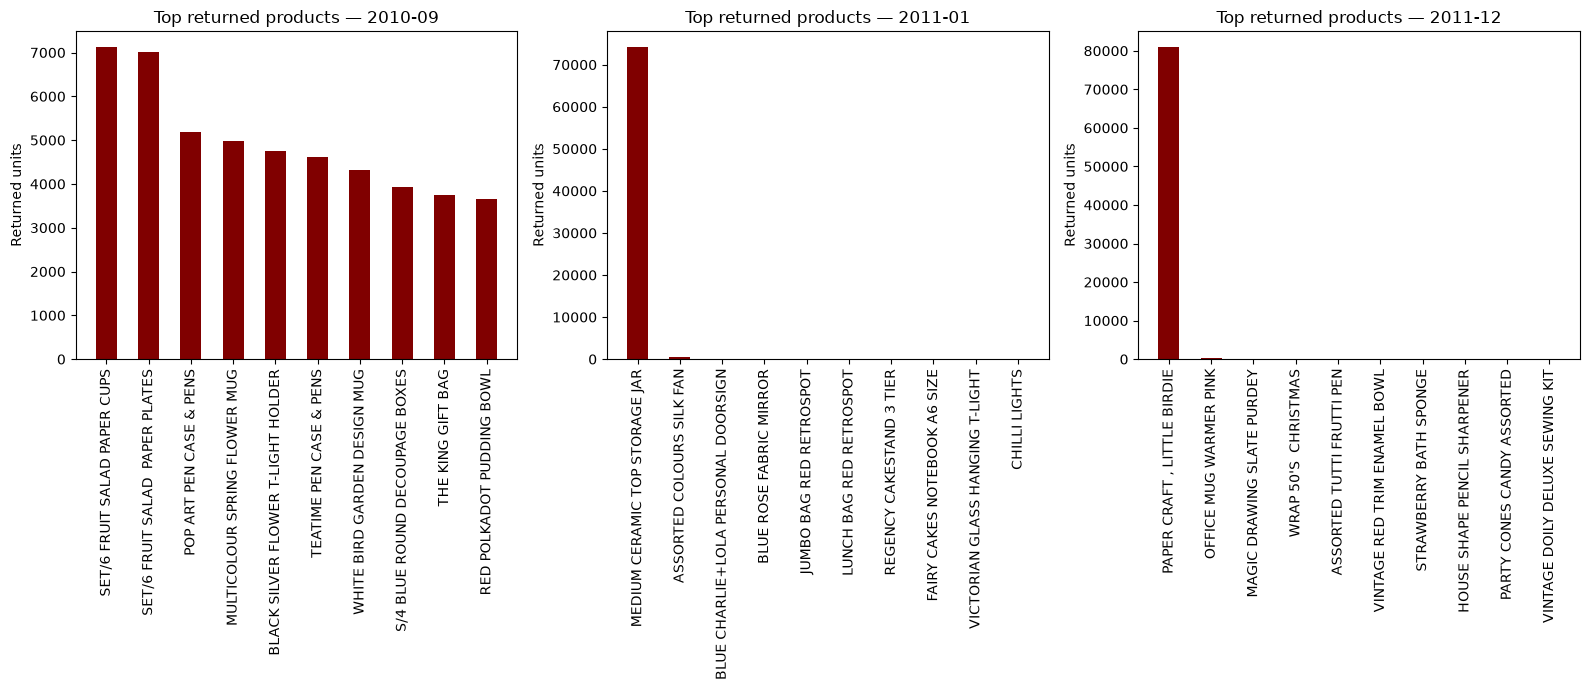

In [81]:
fig,ax = plt.subplots(1,3,figsize=(16,7))
top_10_prod = {}

for i,month in enumerate(months):
    df_returns["InvoiceDate"] = pd.to_datetime(df_returns["InvoiceDate"])
    df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

    mask_sales = df_sales["InvoiceDate"].dt.strftime("%Y-%m") == month
    mask_returns = df_returns["InvoiceDate"].dt.strftime("%Y-%m") == month

    df_month_sales = df_sales[mask_sales]
    df_month_returns = df_returns[mask_returns]

    top_10_prod[month] = (df_month_returns.groupby(["StockCode", "Description"], as_index=False)["Quantity"]
        .sum()
        .assign(Quantity=lambda x: x["Quantity"].abs())
        .sort_values("Quantity", ascending=False)
        .head(10))
    df_top = top_10_prod[month]

    ax[i].bar(df_top["Description"],df_top["Quantity"], width=0.5,color="maroon")
    ax[i].set_title(f"Top returned products — {month}")
    ax[i].set_ylabel("Returned units")
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

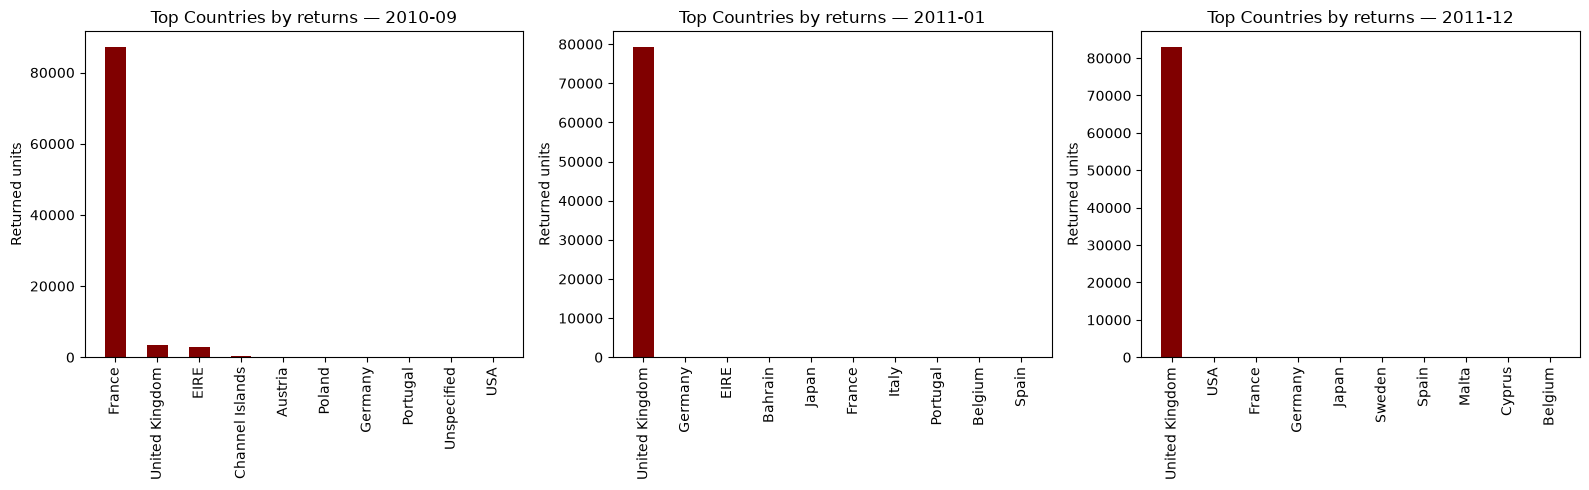

In [82]:
fig,ax = plt.subplots(1,3,figsize=(16,5))
top_10_country = {}

for i,month in enumerate(months):
    df_returns["InvoiceDate"] = pd.to_datetime(df_returns["InvoiceDate"])
    df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

    mask_sales = df_sales["InvoiceDate"].dt.strftime("%Y-%m") == month
    mask_returns = df_returns["InvoiceDate"].dt.strftime("%Y-%m") == month

    df_month_sales = df_sales[mask_sales]
    df_month_returns = df_returns[mask_returns]

    top_10_country[month] = (df_month_returns.groupby(["Country"], as_index=False)["Quantity"]
            .sum()
            .assign(Quantity=lambda x: x["Quantity"].abs())
            .sort_values("Quantity", ascending=False)
            .head(10))
    df_top = top_10_country[month]
    
    ax[i].bar(df_top["Country"],df_top["Quantity"], width=0.5,color="maroon")
    ax[i].set_title(f"Top Countries by returns — {month}")
    ax[i].set_ylabel("Returned units")
    ax[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The three outlier months correspond to distinct events: September 2010 shows an unusually high number of returns across multiple products, predominantly from France, suggesting a possible issue with a specific distributor or customer. January 2011 and December 2011 are each driven by large-volume returns of a single product from the UK, likely reflecting individual bulk order cancellations rather than a systemic increase in return rate.
These months are retained in the analysis as they represent valid transactions, but are noted as exceptional events that disproportionately influence the monthly return rate.

In [109]:
sept_returns = df_ret_month[df_ret_month["year_month"]=="2010-09"]["return_volume"].item()
sept_returns_country = top_10_country["2010-09"]
sept_france = sept_returns_country[sept_returns_country["Country"]=="France"]["Quantity"].item()


jan_returns = df_ret_month[df_ret_month["year_month"]=="2011-01"]["return_volume"].item()
jan_returns_prod = top_10_prod["2011-01"]
jan_returns_country = top_10_country["2011-01"]
jan_uk = jan_returns_country[jan_returns_country["Country"]=="United Kingdom"]["Quantity"].item()
jan_prod = jan_returns_prod.iloc[0]["Quantity"].item()
jan_code = jan_returns_prod.iloc[0]["StockCode"]
jan_name = jan_returns_prod.iloc[0]["Description"]


dec_returns = df_ret_month[df_ret_month["year_month"]=="2011-12"]["return_volume"].item()
dec_returns_prod = top_10_prod["2011-12"]
dec_returns_country = top_10_country["2011-12"]
dec_uk = dec_returns_country[dec_returns_country["Country"]=="United Kingdom"]["Quantity"].item()
dec_prod = dec_returns_prod.iloc[0]["Quantity"].item()
dec_code = dec_returns_prod.iloc[0]["StockCode"]
dec_name = dec_returns_prod.iloc[0]["Description"]

In [44]:
print(f"SEPTEMBER 2010:\nTotal returns: {sept_returns}\nReturns from France: {sept_france} ({sept_france/sept_returns*100:.2f}% of total returns).\n")
print(f"JANUARY 2011:\nTotal returns: {jan_returns}\nReturns from UK: {jan_uk} ({jan_uk/jan_returns*100:.2f}% of total returns).\nReturns of product {jan_code}: {jan_prod} ({jan_prod/jan_returns*100:.2f}% of total returns.)\n")
print(f"DECEMBER 2011:\nTotal returns: {dec_returns}\nReturns from UK: {dec_uk} ({dec_uk/dec_returns*100:.2f}% of total returns).\nReturns of product {dec_code}: {dec_prod} ({dec_prod/dec_returns*100:.2f}% of total returns.)\n")

SEPTEMBER 2010:
Total returns: 94247
Returns from France: 87223 (92.55% of total returns).

JANUARY 2011:
Total returns: 79783
Returns from UK: 79307 (99.40% of total returns).
Returns of product 23166: 74215 (93.02% of total returns.)

DECEMBER 2011:
Total returns: 83538
Returns from UK: 83004 (99.36% of total returns).
Returns of product 23843: 80995 (96.96% of total returns.)



The analysis of outlier months reveals that the unusual peaks in return rate are not data anomalies but valid transactions, likely driven by issues with specific distributors or bulk order cancellations. For this reason, these records are retained in the analysis. However, when investigating returns by country and by product, results will be presented both including and excluding these transactions, in order to assess their influence on the overall findings.    
Specifically, when excluding these transactions, all returns from France will be removed in the month of September 2010, while for January and December of 2011 the specific products that were returned in bul will not be considered.

### 2.5.2 Returns by country

In [83]:
q_country_ret = """
    SELECT 
    s.Country,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT Country, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY Country
    ) s
    LEFT JOIN (
        SELECT Country, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY Country
    ) r ON s.Country = r.Country
    ORDER BY return_volume DESC
    """



q_country_nopeaks = """
    SELECT 
    s.Country,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT Country, SUM(Quantity) AS sales_volume 
        FROM sales
        WHERE NOT ((strftime('%Y-%m', InvoiceDate) = '2010-09' AND Country = 'France')
            OR (strftime('%Y-%m', InvoiceDate) = '2011-01' AND StockCode = '23166')
            OR (strftime('%Y-%m', InvoiceDate) = '2011-12' AND Country = '23843'))
        GROUP BY Country
    ) s
    LEFT JOIN (
        SELECT Country, SUM(ABS(Quantity)) AS return_volume
        FROM returns 
        WHERE NOT ((strftime('%Y-%m', InvoiceDate) = '2010-09' AND Country = 'France')
                    OR (strftime('%Y-%m', InvoiceDate) = '2011-01' AND StockCode = '23166')
                    OR (strftime('%Y-%m', InvoiceDate) = '2011-12' AND Country = '23843'))
        GROUP BY Country
    ) r ON s.Country = r.Country
    ORDER BY return_volume DESC
    """

df_country_ret = pd.read_sql(q_country_ret, engine)
df_country_nopeaks = pd.read_sql(q_country_nopeaks, engine)


In [84]:
tot_sales = df_country_ret["sales_volume"].sum()
tot_returns = df_country_ret["return_volume"].sum()
tot_sales_nopeaks = df_country_nopeaks["sales_volume"].sum()
tot_returns_nopeaks = df_country_nopeaks["return_volume"].sum()

df_country_ret["sales_pct"]=(df_country_ret["sales_volume"]/tot_sales)*100
df_country_ret["returns_pct"]=(df_country_ret["return_volume"]/tot_returns)*100
df_country_nopeaks["sales_pct"]=(df_country_nopeaks["sales_volume"]/tot_sales_nopeaks)*100
df_country_nopeaks["returns_pct"]=(df_country_nopeaks["return_volume"]/tot_returns_nopeaks)*100

Text(0, 0.5, '% of Total Returns')

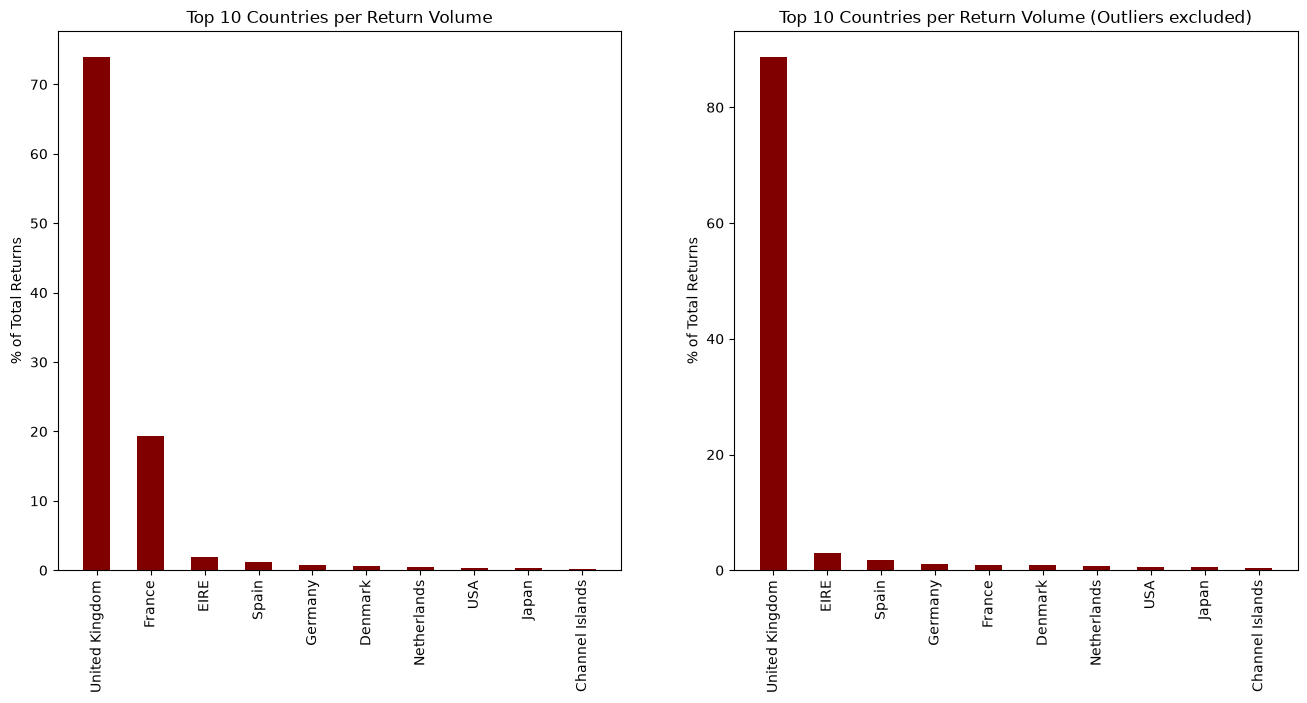

In [69]:
fig,ax = plt.subplots(1,2,figsize=(16,7))

ax[0].bar(df_country_ret["Country"][:10], df_country_ret["returns_pct"][:10], width=0.5, color="maroon")
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Top 10 Countries per Return Volume")
ax[0].set_ylabel("% of Total Returns")

ax[1].bar(df_country_nopeaks["Country"][:10], df_country_nopeaks["returns_pct"][:10], width=0.5, color="maroon")
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Top 10 Countries per Return Volume (Outliers excluded)")
ax[1].set_ylabel("% of Total Returns")


In [86]:
df_country_ret[["Country","sales_pct","returns_pct"]].head()

,Country,sales_pct,returns_pct
0,United Kingdom,82.030282,73.956044
1,France,2.415308,19.300038
2,EIRE,3.002268,1.952794
3,Spain,0.446380,1.205798
4,Germany,1.991529,0.706162


In [87]:
df_country_nopeaks[["Country","sales_pct","returns_pct"]].head()

,Country,sales_pct,returns_pct
0,United Kingdom,81.961255,88.705591
1,EIRE,3.024165,2.982024
2,Spain,0.449635,1.841320
3,Germany,2.006054,1.078348
4,France,2.370891,0.996076


Ase expected, the highest volume of returns comes from the United Kingdom, which is a direct consequence of the UK contributing to 82.03% of total sales. This is confirmed by its low return rate of 2.98%, indicating that a very small portion of purchased products is returned.     
Although the UK was responsible for the majority of sales of January and December 2011, removing the outlier months from the analysis does not significantly influence its statistics. The strongest influence is instead on France, whose contribution to total returns drops from 19.03% to 0.99%, suggesting that the September 2010 peak in returns is not aligned with the common France trend in returns.       

For a more comprehensive understanding, let us also visualize the ranking by return rate.

In [88]:
df_country_ret.sort_values(by=["return_rate"], ascending=False, inplace=True)
df_country_nopeaks.sort_values(by=["return_rate"], ascending=False, inplace=True)

Text(0, 0.5, 'Return Rate (%)')

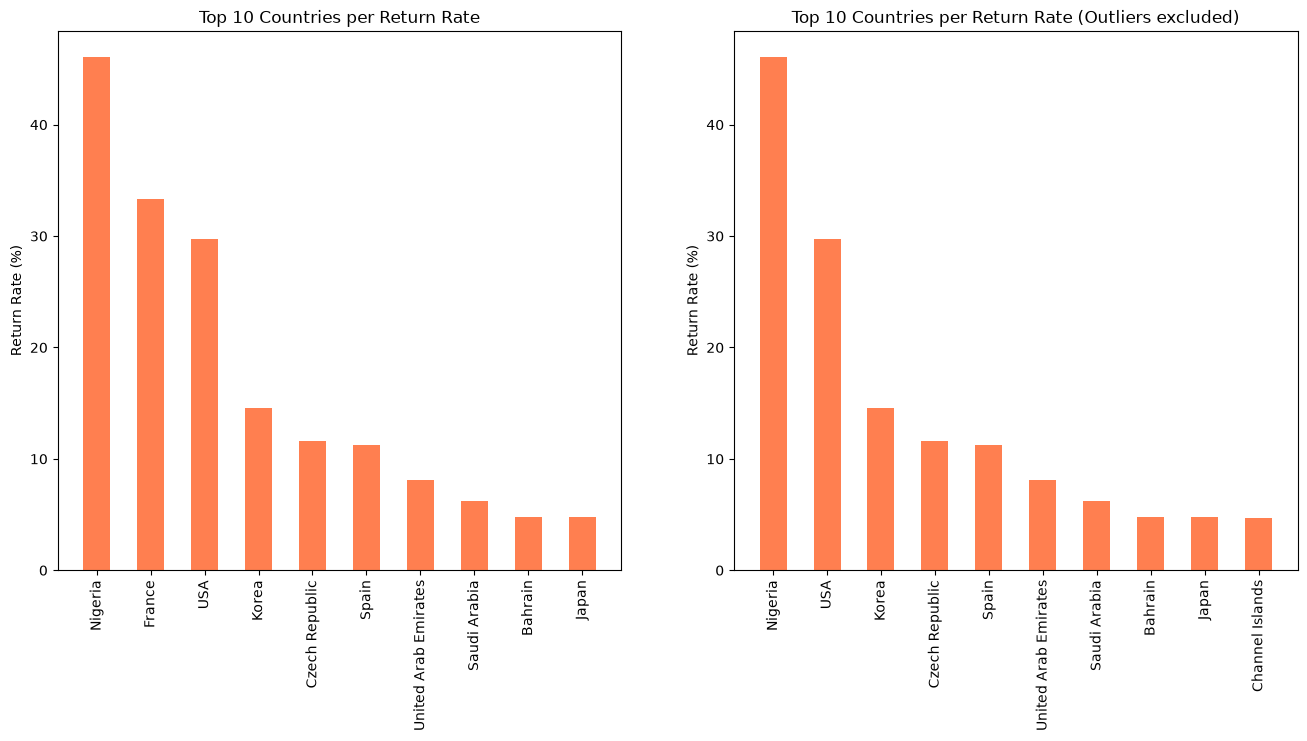

In [77]:
fig,ax = plt.subplots(1,2,figsize=(16,7))

ax[0].bar(df_country_ret["Country"][:10], df_country_ret["return_rate"][:10], width=0.5, color="coral")
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Top 10 Countries per Return Rate")
ax[0].set_ylabel("Return Rate (%)")

ax[1].bar(df_country_nopeaks["Country"][:10], df_country_nopeaks["return_rate"][:10], width=0.5, color="coral")
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Top 10 Countries per Return Rate (Outliers excluded)")
ax[1].set_ylabel("Return Rate (%)")


In [90]:
df_country_ret[["Country","sales_volume", "return_volume","return_rate"]].head()

,Country,sales_volume,return_volume,return_rate
26,Nigeria,102,47,46.08
1,France,270582,90274,33.36
7,USA,5259,1564,29.74
20,Korea,700,102,14.57
22,Czech Republic,670,78,11.64


In [89]:
df_country_nopeaks[["Country","sales_volume", "return_volume","return_rate"]].head()

,Country,sales_volume,return_volume,return_rate
26,Nigeria,102,47,46.08
7,USA,5259,1564,29.74
20,Korea,700,102,14.57
22,Czech Republic,670,78,11.64
2,Spain,50007,5640,11.28


In [91]:
df_country_nopeaks[df_country_nopeaks["Country"]=="France"][["Country","sales_volume", "return_volume","return_rate"]]

,Country,sales_volume,return_volume,return_rate
4,France,263683,3051,1.16


The country with highest return rate is Nigeria, with a 46.08% return rate — meaning that almost half of the purchased items is returned. The country has, however, a negligible impact on revenue loss for the company, due to its extremely low sales volume.

Removing the outlier transactions significantly affects the country rankings by return rate. The most notable case is France: including all transactions, France has an overall return rate of 33.36% — meaning more than a third of all purchased items are returned — and accounts for 19.3% of total returns, placing it among the highest-return countries. However, excluding the September 2010 peak, the return rate for France drops to 1.16%, with a contribution of just 0.99% to total returns.

This confirms that the September 2010 spike was an isolated event specific to French orders, rather than a structural pattern in French customer behaviour.

The following scatter plot illustrates the relationship between return volume (as a percentage of total returns, x-axis) and return rate (y-axis) for each country, with point color indicating sales volume. The choice to exclude outlier months from this visualization was made as a consequence of previous findings, as it was deemed more meaningful to visualize structural patterns at this stage, rather than including episodic events.    
 
Countries in the upper right quadrant combine a high share of total returns with a high return rate, representing the most problematic cases. Point color allows to distinguish between countries with genuinely high return rates and those whose high return volume is simply a consequence of high sales activity.

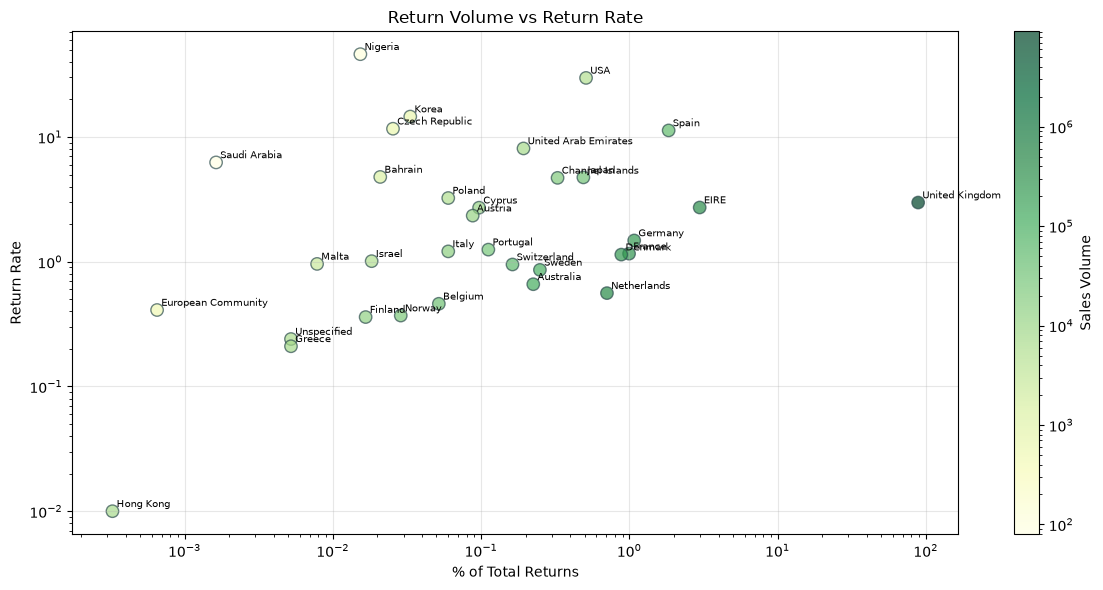

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(df_country_nopeaks["returns_pct"],df_country_nopeaks["return_rate"],c=df_country_nopeaks["sales_volume"],cmap="YlGn",
                     alpha=0.7,norm=LogNorm(),edgecolor="darkslategrey",s=80)

plt.colorbar(scatter, ax=ax, label="Sales Volume")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("% of Total Returns")
ax.set_ylabel("Return Rate")
ax.set_title("Return Volume vs Return Rate")
ax.grid(alpha=0.3)

for _, row in df_country_nopeaks.iterrows():
    ax.annotate(row["Country"],
                xy=(row["returns_pct"], row["return_rate"]),
                fontsize=7,
                xytext=(3, 3),
                textcoords="offset points")

plt.tight_layout()
plt.show()


### 2.5.3 Returns by product

This sections aims to understand the relationship between specific products and return rates.    
Identifying possible "problematic" products, i.e. products with high return volume, is paramount to understand sistematic issues with said items that may negatively impact the company's profit.

In [152]:
q_prod_ret = """
    SELECT 
    s.stock_code,
    s.Description,
    s.sales_volume,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT UPPER(StockCode) as stock_code, Description, SUM(Quantity) AS sales_volume 
        FROM sales 
        GROUP BY stock_code
    ) s
    LEFT JOIN (
        SELECT UPPER(StockCode) as stock_code, Description, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY stock_code
    ) r ON s.stock_code = r.stock_code
    ORDER BY return_rate DESC
    """

df_prod_ret = pd.read_sql(q_prod_ret, engine)

tot_sales = df_prod_ret["sales_volume"].sum()
tot_returns = df_prod_ret["return_volume"].sum()
df_prod_ret["sales_pct"]=(df_prod_ret["sales_volume"]/tot_sales)*100
df_prod_ret["returns_pct"]=(df_prod_ret["return_volume"]/tot_returns)*100

In [153]:
df_prod_ret[:][:5]

,stock_code,Description,sales_volume,return_volume,return_rate,sales_pct,returns_pct
0,35976B,WHITE SCANDINAVIAN HEART CHRISTMAS,1,12,1200.0,0.000009,0.002566
1,79301,FEATHER HEART LIGHTS,1,9,900.0,0.000009,0.001924
2,85043,RED HEART CANDY POP LIGHTS,1,3,300.0,0.000009,0.000641
3,37451,CERAMIC CAKE TEAPOT WITH CHERRY,1,2,200.0,0.000009,0.000428
4,85069,CREAM SWEETHEART DOUBLE SHELF,3,6,200.0,0.000027,0.001283


In [154]:
print(f"{len(df_prod_ret[df_prod_ret["return_rate"]>=100])} products have return rate>=100%.")

19 products have return rate>=100%.


Since 19 products have a return rate higher than 100%, they will kept out of further analysis. This issue, in fact, is probably caused by untracked sales from previous years, which are not reported in the database of interest.    
A return rate computed on incomplete sales data is not meaningful and cannot be considered a valid metric.   

In regards to the return peaks observed in the analysis on returns by country, however, products returned in those months will still be kept into consideration, as a massive return of a specific product can be extremely informative of issues with that product.  

In [155]:
df_plot = df_prod_ret[df_prod_ret["return_rate"] <= 100].head(20)

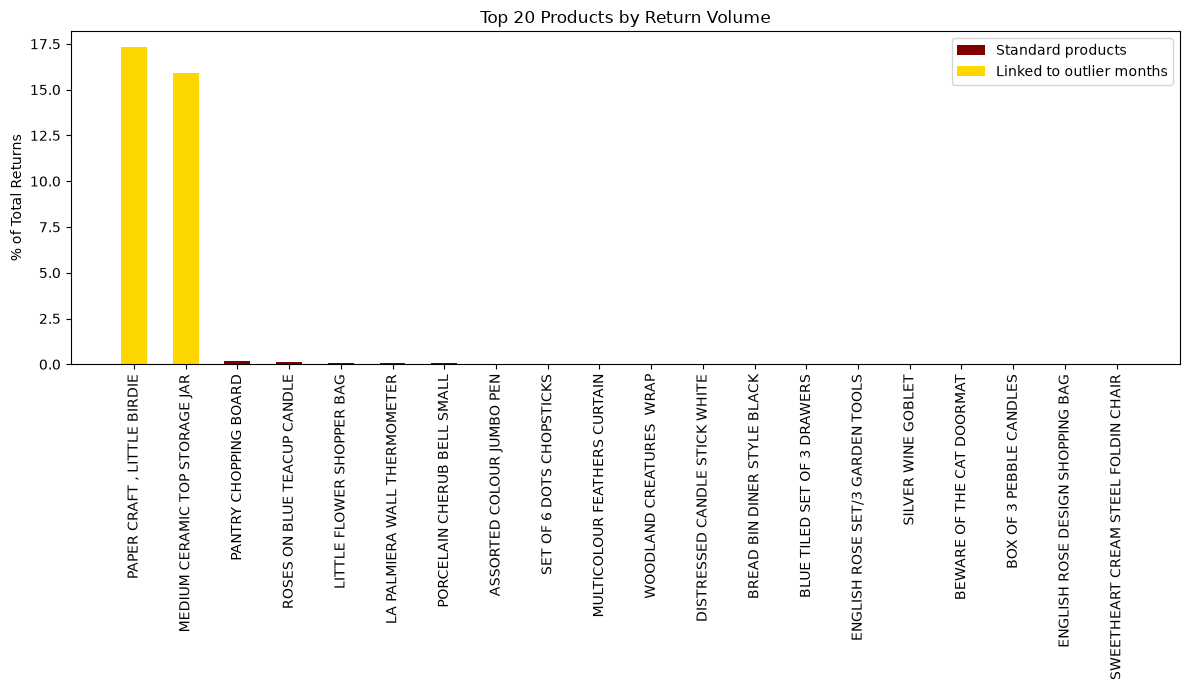

In [156]:
outliers = [jan_name, dec_name]
df_plot.sort_values(by=["return_volume"], ascending=False, inplace=True)

colors = ["gold" if desc in outliers else "maroon" 
          for desc in df_plot["Description"]]

plt.figure(figsize=(12, 7))
bars = plt.bar(df_plot["Description"], df_plot["returns_pct"], 
               width=0.5, color=colors)
plt.xticks(rotation=90)
plt.title("Top 20 Products by Return Volume")
plt.ylabel("% of Total Returns")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="maroon", label="Standard products"),
    Patch(facecolor="gold", label="Linked to outlier months")
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [157]:
df_plot[["Description","sales_volume", "return_volume"]].head()

,Description,sales_volume,return_volume
16,"PAPER CRAFT , LITTLE BIRDIE",80995,80995
19,MEDIUM CERAMIC TOP STORAGE JAR,78033,74494
23,PANTRY CHOPPING BOARD,1154,946
20,ROSES ON BLUE TEACUP CANDLE,539,504
8,LITTLE FLOWER SHOPPER BAG,400,400


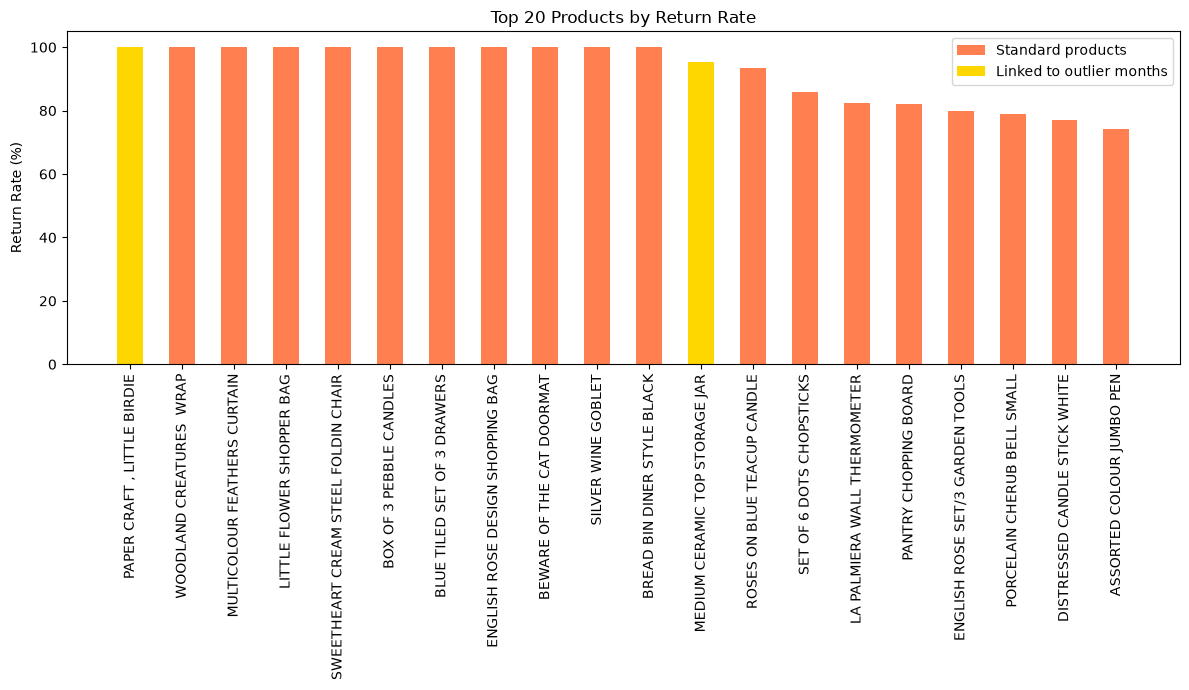

In [158]:
df_plot.sort_values(by=["return_rate"], ascending=False, inplace=True)
colors = ["gold" if desc in outliers else "coral" 
          for desc in df_plot["Description"]]

plt.figure(figsize=(12, 7))
bars = plt.bar(df_plot["Description"], df_plot["return_rate"], 
               width=0.5, color=colors)
plt.xticks(rotation=90)
plt.title("Top 20 Products by Return Rate")
plt.ylabel("Return Rate (%)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="coral", label="Standard products"),
    Patch(facecolor="gold", label="Linked to outlier months")
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [159]:
df_plot[["Description","return_rate"]].head()

,Description,return_rate
16,"PAPER CRAFT , LITTLE BIRDIE",100.0
13,WOODLAND CREATURES WRAP,100.0
17,MULTICOLOUR FEATHERS CURTAIN,100.0
8,LITTLE FLOWER SHOPPER BAG,100.0
12,SWEETHEART CREAM STEEL FOLDIN CHAIR,100.0


The products linked to outlier months are, expectedly, extremely high in ranking for return volume and return rate.    
In might be worth investigating whetere these pteo products were purchased and returned in bulk, which might indicate a problem with the order, or if the high number of returns is associated to multiple transactions.

#### **Outlier products analysis**

In [192]:
outlier_codes = [jan_code, dec_code]

q_outlier_ret_jan = f"""
    SELECT Description, Invoice, SUM(ABS(Quantity)) AS returned_quantity, "Customer ID"
    FROM returns
    WHERE StockCode = {jan_code}
    GROUP BY Invoice
    ORDER BY returned_quantity DESC
    """
q_outlier_sal_jan = f"""
    SELECT Description, Invoice, SUM(ABS(Quantity)) AS purchased_quantity, "Customer ID"
    FROM sales
    WHERE StockCode = {jan_code}
    GROUP BY Invoice
    ORDER BY purchased_quantity DESC
    """
df_outliers_ret_jan = pd.read_sql(q_outlier_ret_jan, engine)
df_outliers_sal_jan = pd.read_sql(q_outlier_sal_jan, engine)

q_outlier_ret_dec = f"""
    SELECT Description, Invoice, SUM(ABS(Quantity)) AS returned_quantity, "Customer ID"
    FROM returns
    WHERE StockCode = {dec_code}
    GROUP BY Invoice
    ORDER BY returned_quantity DESC
    """
q_outlier_sal_dec = f"""
    SELECT Description, Invoice, SUM(ABS(Quantity)) AS purchased_quantity, "Customer ID"
    FROM sales
    WHERE StockCode = {dec_code}
    GROUP BY Invoice
    ORDER BY purchased_quantity DESC
    """

df_outliers_ret_dec = pd.read_sql(q_outlier_ret_dec, engine)
df_outliers_sal_dec = pd.read_sql(q_outlier_sal_dec, engine)

In [193]:
# January outlier
df_outliers_ret_jan

,Description,Invoice,returned_quantity,Customer ID
0,MEDIUM CERAMIC TOP STORAGE JAR,C541433,74215,12346.0
1,MEDIUM CERAMIC TOP STORAGE JAR,C557508,240,16684.0
2,MEDIUM CERAMIC TOP STORAGE JAR,C570867,12,12607.0
3,MEDIUM CERAMIC TOP STORAGE JAR,C562375,12,14911.0
4,MEDIUM CERAMIC TOP STORAGE JAR,C554527,9,15251.0
5,MEDIUM CERAMIC TOP STORAGE JAR,C567677,2,12409.0
6,MEDIUM CERAMIC TOP STORAGE JAR,C572991,1,17672.0
7,MEDIUM CERAMIC TOP STORAGE JAR,C567535,1,15253.0
8,MEDIUM CERAMIC TOP STORAGE JAR,C562952,1,12749.0
9,MEDIUM CERAMIC TOP STORAGE JAR,C560540,1,12415.0


In [194]:
df_outliers_sal_jan

,Description,Invoice,purchased_quantity,Customer ID
0,MEDIUM CERAMIC TOP STORAGE JAR,541431,74215,12346.0
1,MEDIUM CERAMIC TOP STORAGE JAR,561901,288,14156.0
2,MEDIUM CERAMIC TOP STORAGE JAR,553607,240,16684.0
3,MEDIUM CERAMIC TOP STORAGE JAR,561051,144,16684.0
4,MEDIUM CERAMIC TOP STORAGE JAR,580665,96,16684.0
...,...,...,...,...
242,MEDIUM CERAMIC TOP STORAGE JAR,557937,1,NaN
243,MEDIUM CERAMIC TOP STORAGE JAR,557502,1,NaN
244,MEDIUM CERAMIC TOP STORAGE JAR,555149,1,NaN
245,MEDIUM CERAMIC TOP STORAGE JAR,554268,1,15311.0


In [195]:
# December outlier
df_outliers_ret_dec

,Description,Invoice,returned_quantity,Customer ID
0,"PAPER CRAFT , LITTLE BIRDIE",C581484,80995,16446.0


In [196]:
df_outliers_sal_dec

,Description,Invoice,purchased_quantity,Customer ID
0,"PAPER CRAFT , LITTLE BIRDIE",581483,80995,16446.0


Verifying the number of invoices relative to sales and returns of the outlier products highlights a significant difference between the two:    
- **The January outlier**: the number of sales invoices relative to the specific product is significant, with a total number of invoices of 247 with purchased quantity ranging from 1 to 74215. Among the return invoices, only nine are registered, most of which correspond to small return quantities. One invoice stands out dramatically: it contains a return of 74215 units, more than two orders of magnitude larger than the second-largest return. 
Since this product is also associated with a substantial number of sales invoices, the evidence suggests that the January peak is driven by an isolated event affecting a single large order rather than by a systematic increase in return activity. The underlying cause cannot be determined from the available data.

- **The December outlier**: unlike the January case, the product responsible for the December peak is associated with a single sales invoice and a single return invoice, both involving 80995 units and the same customer. No additional sales of this product are recorded in the dataset, making this event highly unusual. Without further information, it is not possible to determine whether it reflects a genuine transaction, a bookkeeping adjustment, or another data recording peculiarity.

#### **Returns vs Price**

As a final step in the returns analysis, we will see whether there is a relationship between the most returned products and their price.

In [4]:
df_returns.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
1,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
2,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
3,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
4,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [7]:
q_prod_ret_price = """
    SELECT 
    s.stock_code,
    s.Description,
    s.sales_volume,
    s.Price,
    COALESCE(r.return_volume, 0) AS return_volume,
    ROUND(COALESCE(r.return_volume, 0) * 100.0 / s.sales_volume, 2) AS return_rate
    FROM (
        SELECT UPPER(StockCode) as stock_code, Description, SUM(Quantity) AS sales_volume, Price
        FROM sales 
        GROUP BY stock_code
    ) s
    LEFT JOIN (
        SELECT UPPER(StockCode) as stock_code, Description, SUM(ABS(Quantity)) AS return_volume 
        FROM returns 
        GROUP BY stock_code
    ) r ON s.stock_code = r.stock_code
    ORDER BY return_rate DESC
    """

df_prod_ret_price = pd.read_sql(q_prod_ret_price,engine)

In [8]:
df_prod_ret_price.head()

,stock_code,Description,sales_volume,Price,return_volume,return_rate
0,35976B,WHITE SCANDINAVIAN HEART CHRISTMAS,1,1.25,12,1200.0
1,79301,FEATHER HEART LIGHTS,1,2.95,9,900.0
2,85043,RED HEART CANDY POP LIGHTS,1,4.95,3,300.0
3,37451,CERAMIC CAKE TEAPOT WITH CHERRY,1,4.95,2,200.0
4,85069,CREAM SWEETHEART DOUBLE SHELF,3,16.95,6,200.0


In [10]:
r = spearmanr(df_prod_ret_price["return_rate"], df_prod_ret_price["Price"])
print(f"Spearman coefficient: {r.statistic:.3f}, p-value: {r.pvalue}")

Spearman coefficient: 0.089, p-value: 9.714646349346037e-10


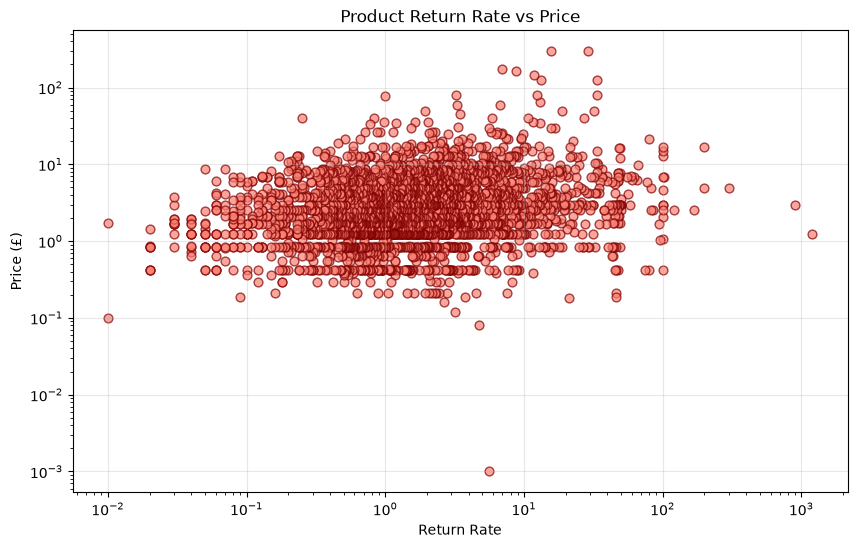

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(
    df_prod_ret_price["return_rate"],
    df_prod_ret_price["Price"],
    color="salmon",
    alpha=0.7,
    edgecolor="maroon",
    s=40)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Return Rate")
plt.ylabel("Price (£)")
plt.title("Product Return Rate vs Price")
plt.grid(alpha=0.3)

The above scatter plot shows an almost constant Price, regardless of the return rate, which is confirmed by the very low Spearman correlation of 0.089. This indicates that price is son a direct influence in the return rate of products.

## 2.6 Customer analysis

In this section, we focus on gaining insight on the company's customer base. We have already gathered some information through previous analysis (e.g. 90.09% of the customers come from the UK), and we will now focus on how they contribute to the total revenue and segment them based on monetary value, frequency of purchases and recency of purchase.    

<div style="background:#00000; padding:12px; border-left:5px solid #3b82f6;">
<b>Note on Customer ID</b><br>
In the preliminary analysis, over 24000 entries with null Customer ID were detected. While the missing customer ID alnone does not constitute a problem for previous analysis, it has now to be taken into account: for the Customer analysis, <strong>all entries with null Customer ID will not be considered</strong>.
</div>

### 2.6.1 Customer revenue distribution

In [177]:
q_cust_rev = """
    SELECT SUM(Quantity*Price) AS revenue, "Customer ID", Country
    FROM (SELECT "Customer ID", Country, Price, Quantity FROM sales
        UNION ALL
        SELECT "Customer ID", Country, Price, Quantity FROM returns
        )
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
    ORDER BY revenue DESC
    """
df_cust_rev = pd.read_sql(q_cust_rev, engine)
df_cust_rev["revenue_pct"] = df_cust_rev["revenue"]/df_cust_rev["revenue"].sum() *100


In [178]:
df_cust_rev.loc[df_cust_rev["Country"] == "United Kingdom", "Country"] = "UK"

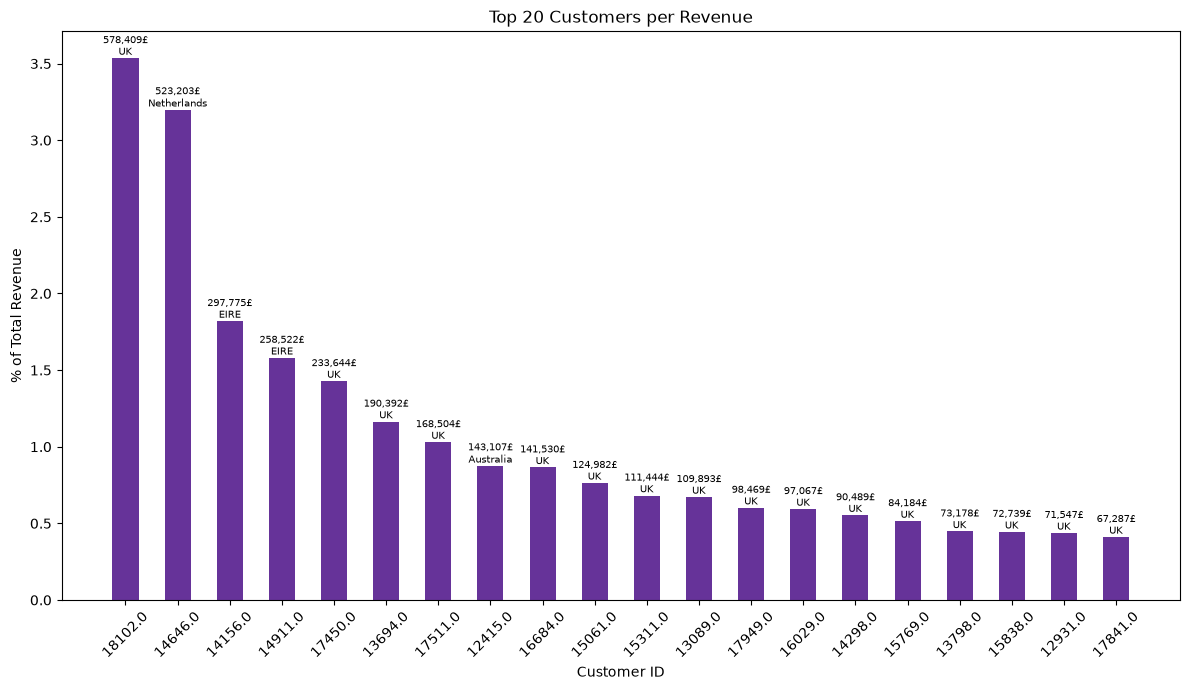

In [179]:
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(df_cust_rev["Customer ID"][:20], 
              df_cust_rev["revenue_pct"][:20], 
              width=0.5, color="rebeccapurple")
for bar, val, country in zip(bars, df_cust_rev["revenue"][:20], df_cust_rev["Country"][:20]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:,.0f}£\n{country}',
            ha='center', va='bottom', fontsize=7)

ax.set_xlabel("Customer ID")
ax.set_ylabel("% of Total Revenue")
ax.set_title("Top 20 Customers per Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As previously computed, the top 23.1% of customers generates 80% of the revenue, and we can clearly see how the top-spending customers mostly come from the UK (highest revenue contributor).

### 2.6.2 RFM Segmentation

In this section, we segment the customers by computing their RFM score.    
Each customer will be assigned a score from 1 to 5 on each of three dimensions:    
- **Recency**: how recently the customer made a purchase; a score of 5 indicates a very recent purchase, 1 indicates a long time ago.
- **Frequency**: how often the customer purchases; a score of 5 indicates a very frequent buyer, 1 indicates a one-time or rare buyer.
- **Monetary value**: how much the customer has spent in total; a score of 5 indicates a high-spending customer, 1 indicates a low-spending customer
    
The three scores are then combined into an overall RFM score, which allows us to segment the customer base into meaningful groups such as top customers, at-risk customers, and occasional buyers.

In [180]:
q_rfm = """
    SELECT s.customer_id,
       s.last_purchase,
       s.frequency,
       s.monetary_avg,
       COALESCE(s.monetary, 0) + COALESCE(r.monetary, 0) AS monetary
FROM (
    SELECT "Customer ID" AS customer_id,
           MAX(InvoiceDate) AS last_purchase,
           COUNT(DISTINCT Invoice) AS frequency,
           SUM(Price * Quantity) AS monetary,
           SUM(Price * Quantity) / COUNT(DISTINCT Invoice) AS monetary_avg
    FROM sales
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
) s
LEFT JOIN (
    SELECT "Customer ID" AS customer_id,
           SUM(Price * Quantity) AS monetary
    FROM returns
    WHERE "Customer ID" IS NOT NULL
    GROUP BY "Customer ID"
) r ON s.customer_id = r.customer_id
    """

df_rfm = pd.read_sql(q_rfm, engine)
df_rfm["last_purchase"] = pd.to_datetime(df_rfm["last_purchase"])

# Compute recency
recent_date = df_rfm['last_purchase'].max()
df_rfm['recency'] = df_rfm['last_purchase'].apply(lambda x: (recent_date - x).days)

In [181]:
# Assign 1-5 score for each dimension based on quantile subdivision
df_rfm['R_score'] = pd.qcut(df_rfm['recency'], q=5, labels=[5,4,3,2,1])
df_rfm['F_score'] = pd.qcut(df_rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
df_rfm['M_score'] = pd.qcut(df_rfm['monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])

In [182]:
# Assign customer segment
df_rfm['RFM_segment'] = df_rfm['R_score'].astype(str) + df_rfm['F_score'].astype(str) + df_rfm['M_score'].astype(str)

In [183]:
df_rfm.head()

,customer_id,last_purchase,frequency,monetary_avg,monetary,recency,R_score,F_score,M_score,RFM_segment
0,12346.0,2011-01-18 10:01:00,3,25784.32000,169.36,325,2,3,1,231
1,12347.0,2011-12-07 15:52:00,8,615.19125,4921.53,1,5,4,5,545
2,12348.0,2011-09-25 13:13:00,5,331.68000,1658.40,74,3,4,4,344
3,12349.0,2011-11-21 09:51:00,3,1226.23000,3654.54,18,5,3,5,535
4,12350.0,2011-02-02 16:01:00,1,294.40000,294.40,309,2,1,2,212


In [184]:
df_rfm['segment'] = df_rfm.apply(segment_customer, axis=1)

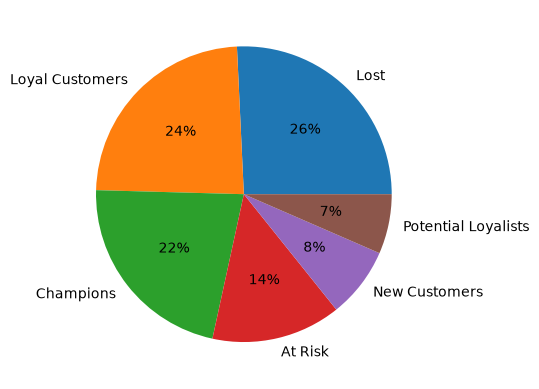

In [ ]:
plt.pie(df_rfm.segment.value_counts(),
        labels=df_rfm.segment.value_counts().index,
        autopct='%.0f%%')
plt.show()

The RFM analysis shows that almost half of the total customer-base ($46$%) is highly loyal; among them, almost half is also high-spending ($22$% of the total).    
Of the remaining $54$%, of particular interest is the number of lost clients which amounts to 1/4 of the total customer-base, while the percentage of new customers is only $8$%.    
    
The following heatmap shows the correlation between Recency, Frequency and Monetary:

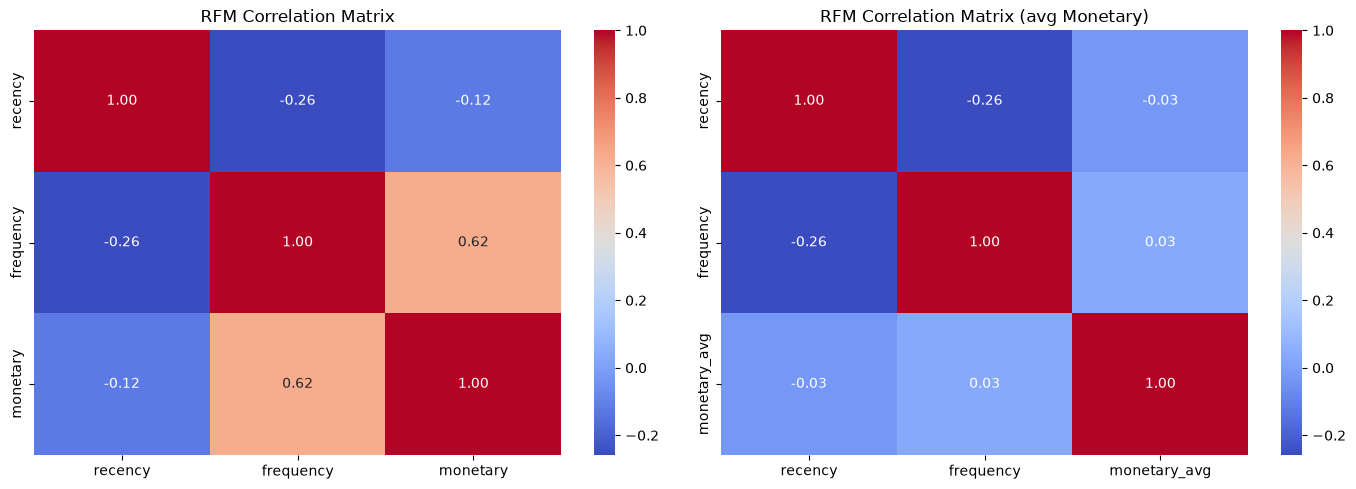

In [50]:
corr_matrix = df_rfm[["recency", "frequency", "monetary"]].corr()
corr_matrix_2 = df_rfm[["recency", "frequency", "monetary_avg"]].corr()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[0])
ax[0].set_title("RFM Correlation Matrix")

sns.heatmap(corr_matrix_2, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1])
ax[1].set_title("RFM Correlation Matrix (avg Monetary)")

plt.tight_layout()
plt.show()

While there is no significant correlation between Monetary and Recency (-0.12) or Frequency and Recency (-0.26), there is a moderate positive correlation of 0.62 between Frequency and Monetary. This is to be expected, as the Monetary value corresponds to the net revenue generated by that customer, which is related to the number of total purchases.   
If we, however, check correlations with the average amount spent per order, we can se that there is no correlation. This is an important results that confirms that the amount spent per order does not depend on the frequency of orders, i.e. customers who purchase more often (while inevitably contributing more to revenue) do not tend to spend more per order.